# Part I — Exploratory Analysis of the Tumor Microenvironment

In this first part, we perform a descriptive analysis of two large hypoxic regions (LHR1 and LHR2) from head and neck squamous cell carcinoma specimens. The goal is to understand the spatial organization of immune cells (CD8, CD68, FoxP3) in relation to hypoxia, necrosis, and tumor architecture. We also provide a first qualitative look at topological features using persistence diagrams and their vectorizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ripser
import persim
from persim import PersistenceImager, PersLandscapeApprox, PersLandscapeExact
from persim.landscapes import plot_landscape_simple
import jinja2

In [2]:
LHR1 = pd.read_csv("LargeHypoxicRegion.csv")
LHR2 = pd.read_csv("LargeHypoxicRegion2.csv")

In [3]:
LHR1.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.86,526.43,0,0,0,0,CD8
1,2.59,573.32,0,0,0,0,CD8
2,9.26,596.48,0,0,0,0,CD8
3,2.55,842.17,0,0,0,0,CD8
4,7.02,1044.55,0,0,0,0,CD8


In [4]:
LHR2.head(5)

,x,y,PanCK+,CAIX+,Pimo+,Necrosis,Celltype
0,2.59,67.20,0,0,0,0,CD8
1,7.99,106.15,0,1,0,0,CD8
2,3.25,373.03,0,0,0,0,CD8
3,8.40,480.41,0,0,0,0,CD8
4,3.93,572.57,0,0,0,0,CD8


In our dataset, we observe three types of immune cells:

- **CD8**: Their primary function is to identify and directly destroy infected or malignant cells. In the tumor microenvironment, a high spatial infiltration of CD8+ T cells within the tumor core is generally associated with a strong anti-tumor immune response and a better patient prognosis

- **CD68**: CD68 is a widely used pan-macrophage marker. These cells are specialized in phagocytosis (engulfing cellular debris and pathogens).

- **FoxP3**: Their primary role is to suppress immune responses and prevent autoimmunity. However, in cancer, a high infiltration of FoxP3 cells is generally a negative sign, as they actively inhibit the tumor-killing functions of the CD8 cells

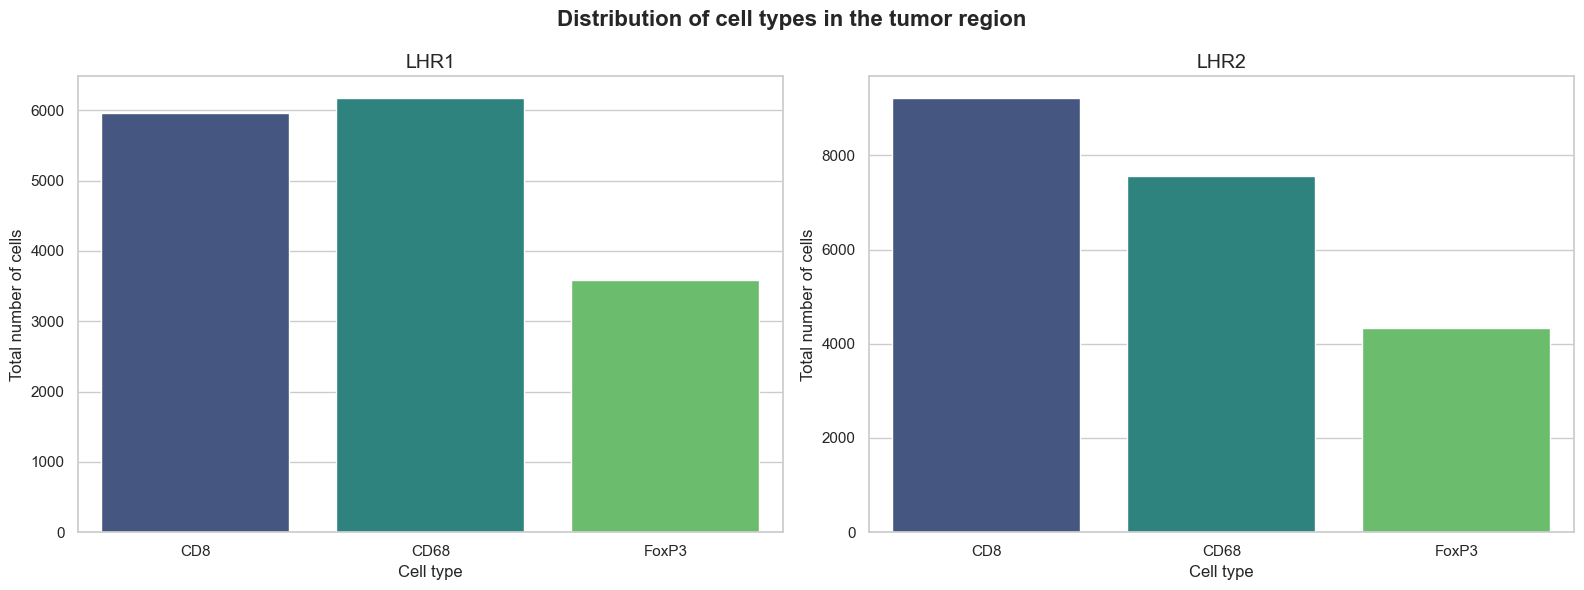

In [5]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of cell types in the tumor region', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)

sns.countplot(data=LHR2, x='Celltype', hue='Celltype', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)

plt.tight_layout()

We observe a similar distribution across both regions: CD8 and CD68 cells are present in roughly equal numbers, while FoxP3 cells are approximately half as numerous. This suggests a balanced presence of cytotoxic (CD8) and phagocytic (CD68) immune cells in the tumor microenvironment, with a smaller but notable regulatory (FoxP3) population. The relatively low proportion of FoxP3 cells compared to CD8 cells could indicate that the anti-tumor immune response is not entirely suppressed in these regions.

Beyond cell type composition, a key factor shaping the tumor microenvironment is oxygen availability. We now investigate the hypoxic state of each cell using molecular markers present in our dataset.

**Hypoxia (Low Oxygen)**: Hypoxia refers to regions within the tissue that are deprived of adequate oxygen. As solid tumors grow rapidly, they often outstrip their local blood supply, creating these oxygen-starved areas. In cancer, hypoxia is a strong negative prognostic factor: it drives tumor aggressiveness, increases resistance to therapies (like radiation), and creates a highly immunosuppressive microenvironment that inhibits the function of CD8+ cells while promoting suppressive cells like FoxP3+.

**CAIX+ / Pimo+ (Hypoxia Markers)**: These are the specific markers used in the dataset to identify hypoxic cells. CAIX (Carbonic Anhydrase IX) is an endogenous protein produced by cells to survive low oxygen levels, while Pimo (Pimonidazole) is an exogenous chemical tracer that specifically binds to oxygen-deprived cells. In the following visualization, we use the CAIX+ marker to assess the hypoxic state of each cell type.

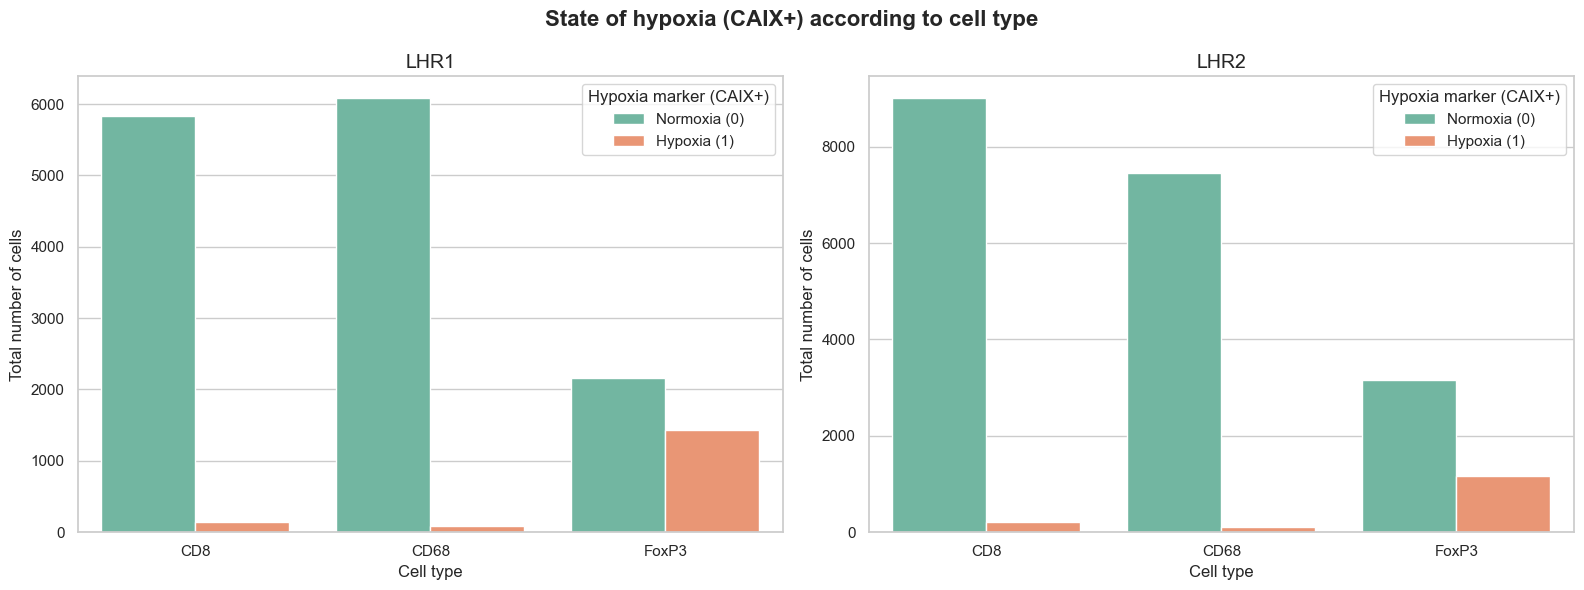

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('State of hypoxia (CAIX+) according to cell type', fontsize=16, fontweight='bold')

sns.countplot(data=LHR1, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[0])
axes[0].set_title('LHR1', fontsize=14)
axes[0].set_xlabel('Cell type', fontsize=12)
axes[0].set_ylabel('Total number of cells', fontsize=12)
axes[0].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

sns.countplot(data=LHR2, x='Celltype', hue='CAIX+', palette='Set2', ax=axes[1])
axes[1].set_title('LHR2', fontsize=14)
axes[1].set_xlabel('Cell type', fontsize=12)
axes[1].set_ylabel('Total number of cells', fontsize=12)
axes[1].legend(title='Hypoxia marker (CAIX+)', labels=['Normoxia (0)', 'Hypoxia (1)'])

plt.tight_layout()

### Observations

**CD8 and CD68 — predominantly normoxic:** In both LHR1 and LHR2, the vast majority of CD8 (cytotoxic) and CD68 (macrophage) cells are in a normoxic state, with very few cells expressing the CAIX+ marker. This indicates that these immune populations reside mainly in well-oxygenated areas of the tumor.

**FoxP3 — a strong hypoxic signature:** In contrast, the FoxP3 (regulatory T-cell) population exhibits a significant proportion of hypoxic cells. This pattern is consistent across both regions, suggesting it is not an artifact but a genuine biological feature.

**Interpretation:** The co-localization of FoxP3 cells with hypoxic zones is consistent with the known biology of the tumor microenvironment: hypoxia promotes immunosuppression by recruiting and sustaining regulatory T-cells, while excluding cytotoxic CD8 cells. This reinforces the idea that oxygen-deprived regions act as immune-privileged niches where the tumor can evade the anti-tumor response.

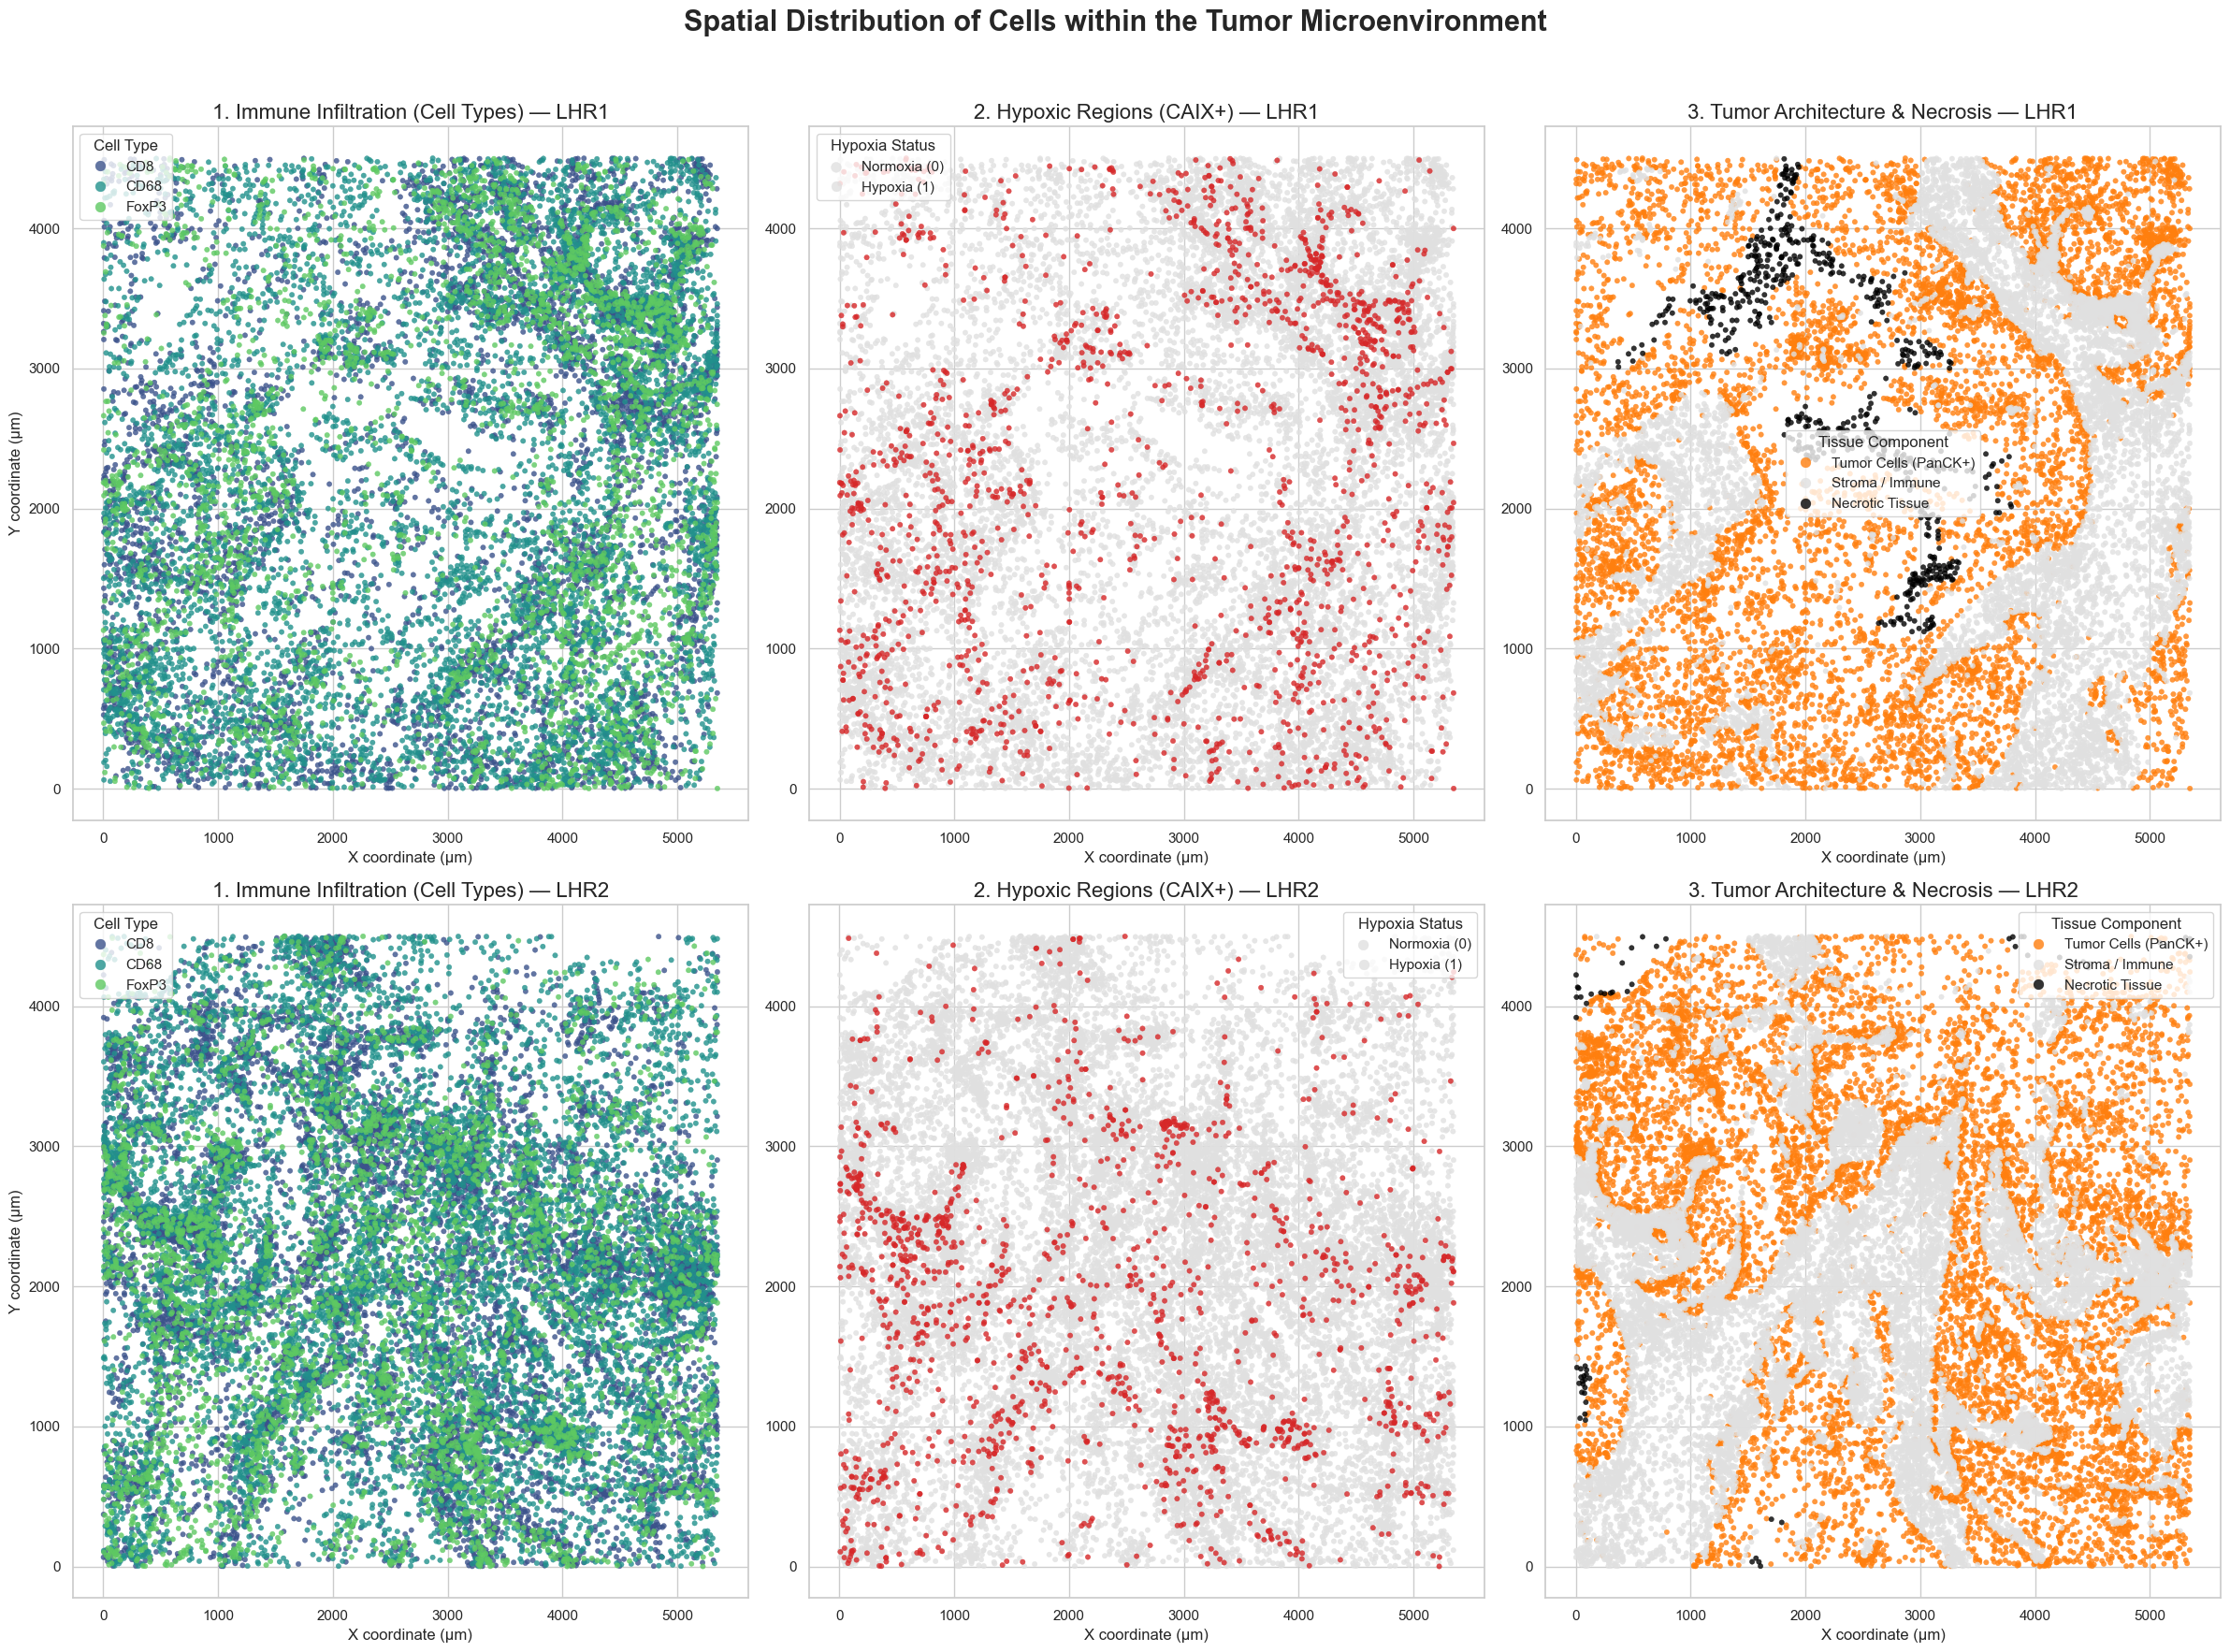

In [7]:
df1 = LHR1.copy()
df2 = LHR2.copy()

for df in [df1, df2]:
    conditions = [
        (df['Necrosis'] == 1),
        (df['PanCK+'] == 1)
    ]
    choices = ['Necrotic Tissue', 'Tumor Cells (PanCK+)']
    df['Tissue_Structure'] = np.select(conditions, choices, default='Stroma / Immune')

fig, axes = plt.subplots(2, 3, figsize=(24, 18))
fig.suptitle('Spatial Distribution of Cells within the Tumor Microenvironment', fontsize=22, fontweight='bold')

for row, (df, label) in enumerate([(df1, 'LHR1'), (df2, 'LHR2')]):
    sns.scatterplot(
        data=df, x='x', y='y', hue='Celltype',
        palette={'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 0]
    )
    axes[row, 0].set_title(f'1. Immune Infiltration (Cell Types) — {label}', fontsize=16)
    axes[row, 0].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 0].set_ylabel('Y coordinate (µm)', fontsize=12)
    axes[row, 0].legend(title='Cell Type', markerscale=2)

    df_sorted_hypoxia = df.sort_values(by='CAIX+')
    sns.scatterplot(
        data=df_sorted_hypoxia, x='x', y='y', hue='CAIX+',
        palette={0: '#e0e0e0', 1: '#d62728'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 1]
    )
    axes[row, 1].set_title(f'2. Hypoxic Regions (CAIX+) — {label}', fontsize=16)
    axes[row, 1].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 1].set_ylabel('')
    axes[row, 1].legend(title='Hypoxia Status', labels=['Normoxia (0)', 'Hypoxia (1)'], markerscale=2)

    df_sorted_structure = df.sort_values(by='Tissue_Structure', ascending=False)
    sns.scatterplot(
        data=df_sorted_structure, x='x', y='y', hue='Tissue_Structure',
        palette={'Stroma / Immune': '#e0e0e0', 'Tumor Cells (PanCK+)': '#ff7f0e', 'Necrotic Tissue': '#000000'},
        s=15, alpha=0.8, edgecolor=None, ax=axes[row, 2]
    )
    axes[row, 2].set_title(f'3. Tumor Architecture & Necrosis — {label}', fontsize=16)
    axes[row, 2].set_xlabel('X coordinate (µm)', fontsize=12)
    axes[row, 2].set_ylabel('')
    axes[row, 2].legend(title='Tissue Component', markerscale=2)

plt.tight_layout(rect=[0, 0, 1, 0.96])

### Observations

**Immune infiltration (panel 1):** CD8, CD68 and FoxP3 cells are spread across the tissue but tend to concentrate at the periphery of the tumor mass rather than within its core. This pattern of immune exclusion is a hallmark of aggressive solid tumors.

**Hypoxic regions (panel 2):** The CAIX+ hypoxic cells (red) form well-defined clusters that are not randomly distributed. They are primarily located around the necrotic cores, forming a gradient of decreasing oxygen from the tumor periphery inward.

**Tumor architecture (panel 3):** The necrotic tissue (black) sits at the center of the tumor mass (orange/PanCK+), surrounded by the hypoxic belt observed in panel 2. The stroma and immune cells (grey) populate the outer margins.

**Cross-panel interpretation:** These three views reveal a concentric spatial organization: a necrotic core, surrounded by a hypoxic ring rich in FoxP3 cells, and an oxygenated periphery where CD8 and CD68 cells are more prevalent. This architecture shows how the tumor's physical structure and metabolic environment shape immune cell distribution, effectively creating a barrier that shields the tumor interior from immune attack. This pattern is consistent across both LHR1 and LHR2.

## Topological Data Analysis (TDA)

The previous visualizations gave us a qualitative understanding of the spatial organization. We now turn to **Topological Data Analysis** to quantify these spatial patterns rigorously.

The idea is to study the **shape** of the point clouds formed by each cell type using persistent homology. For each cell type and region, we build a filtration of simplicial complexes (Vietoris-Rips) at increasing distance scales and track the appearance and disappearance of topological features:

- **$H_0$ (connected components):** Points start as isolated components that merge as the scale increases. Features that persist over a long range indicate well-separated clusters, while short-lived features reflect dense, uniformly distributed cells.
- **$H_1$ (loops/holes):** These capture circular voids in the point cloud. A persistent loop suggests a ring-like arrangement of cells surrounding an empty region — potentially a hole in the immune infiltration pattern (e.g., around a necrotic or hypoxic zone).

Calculating CD8 LHR1: 1500 points...
Calculating CD8 LHR2: 1500 points...
Calculating CD68 LHR1: 1500 points...
Calculating CD68 LHR2: 1500 points...
Calculating FoxP3 LHR1: 1500 points...
Calculating FoxP3 LHR2: 1500 points...


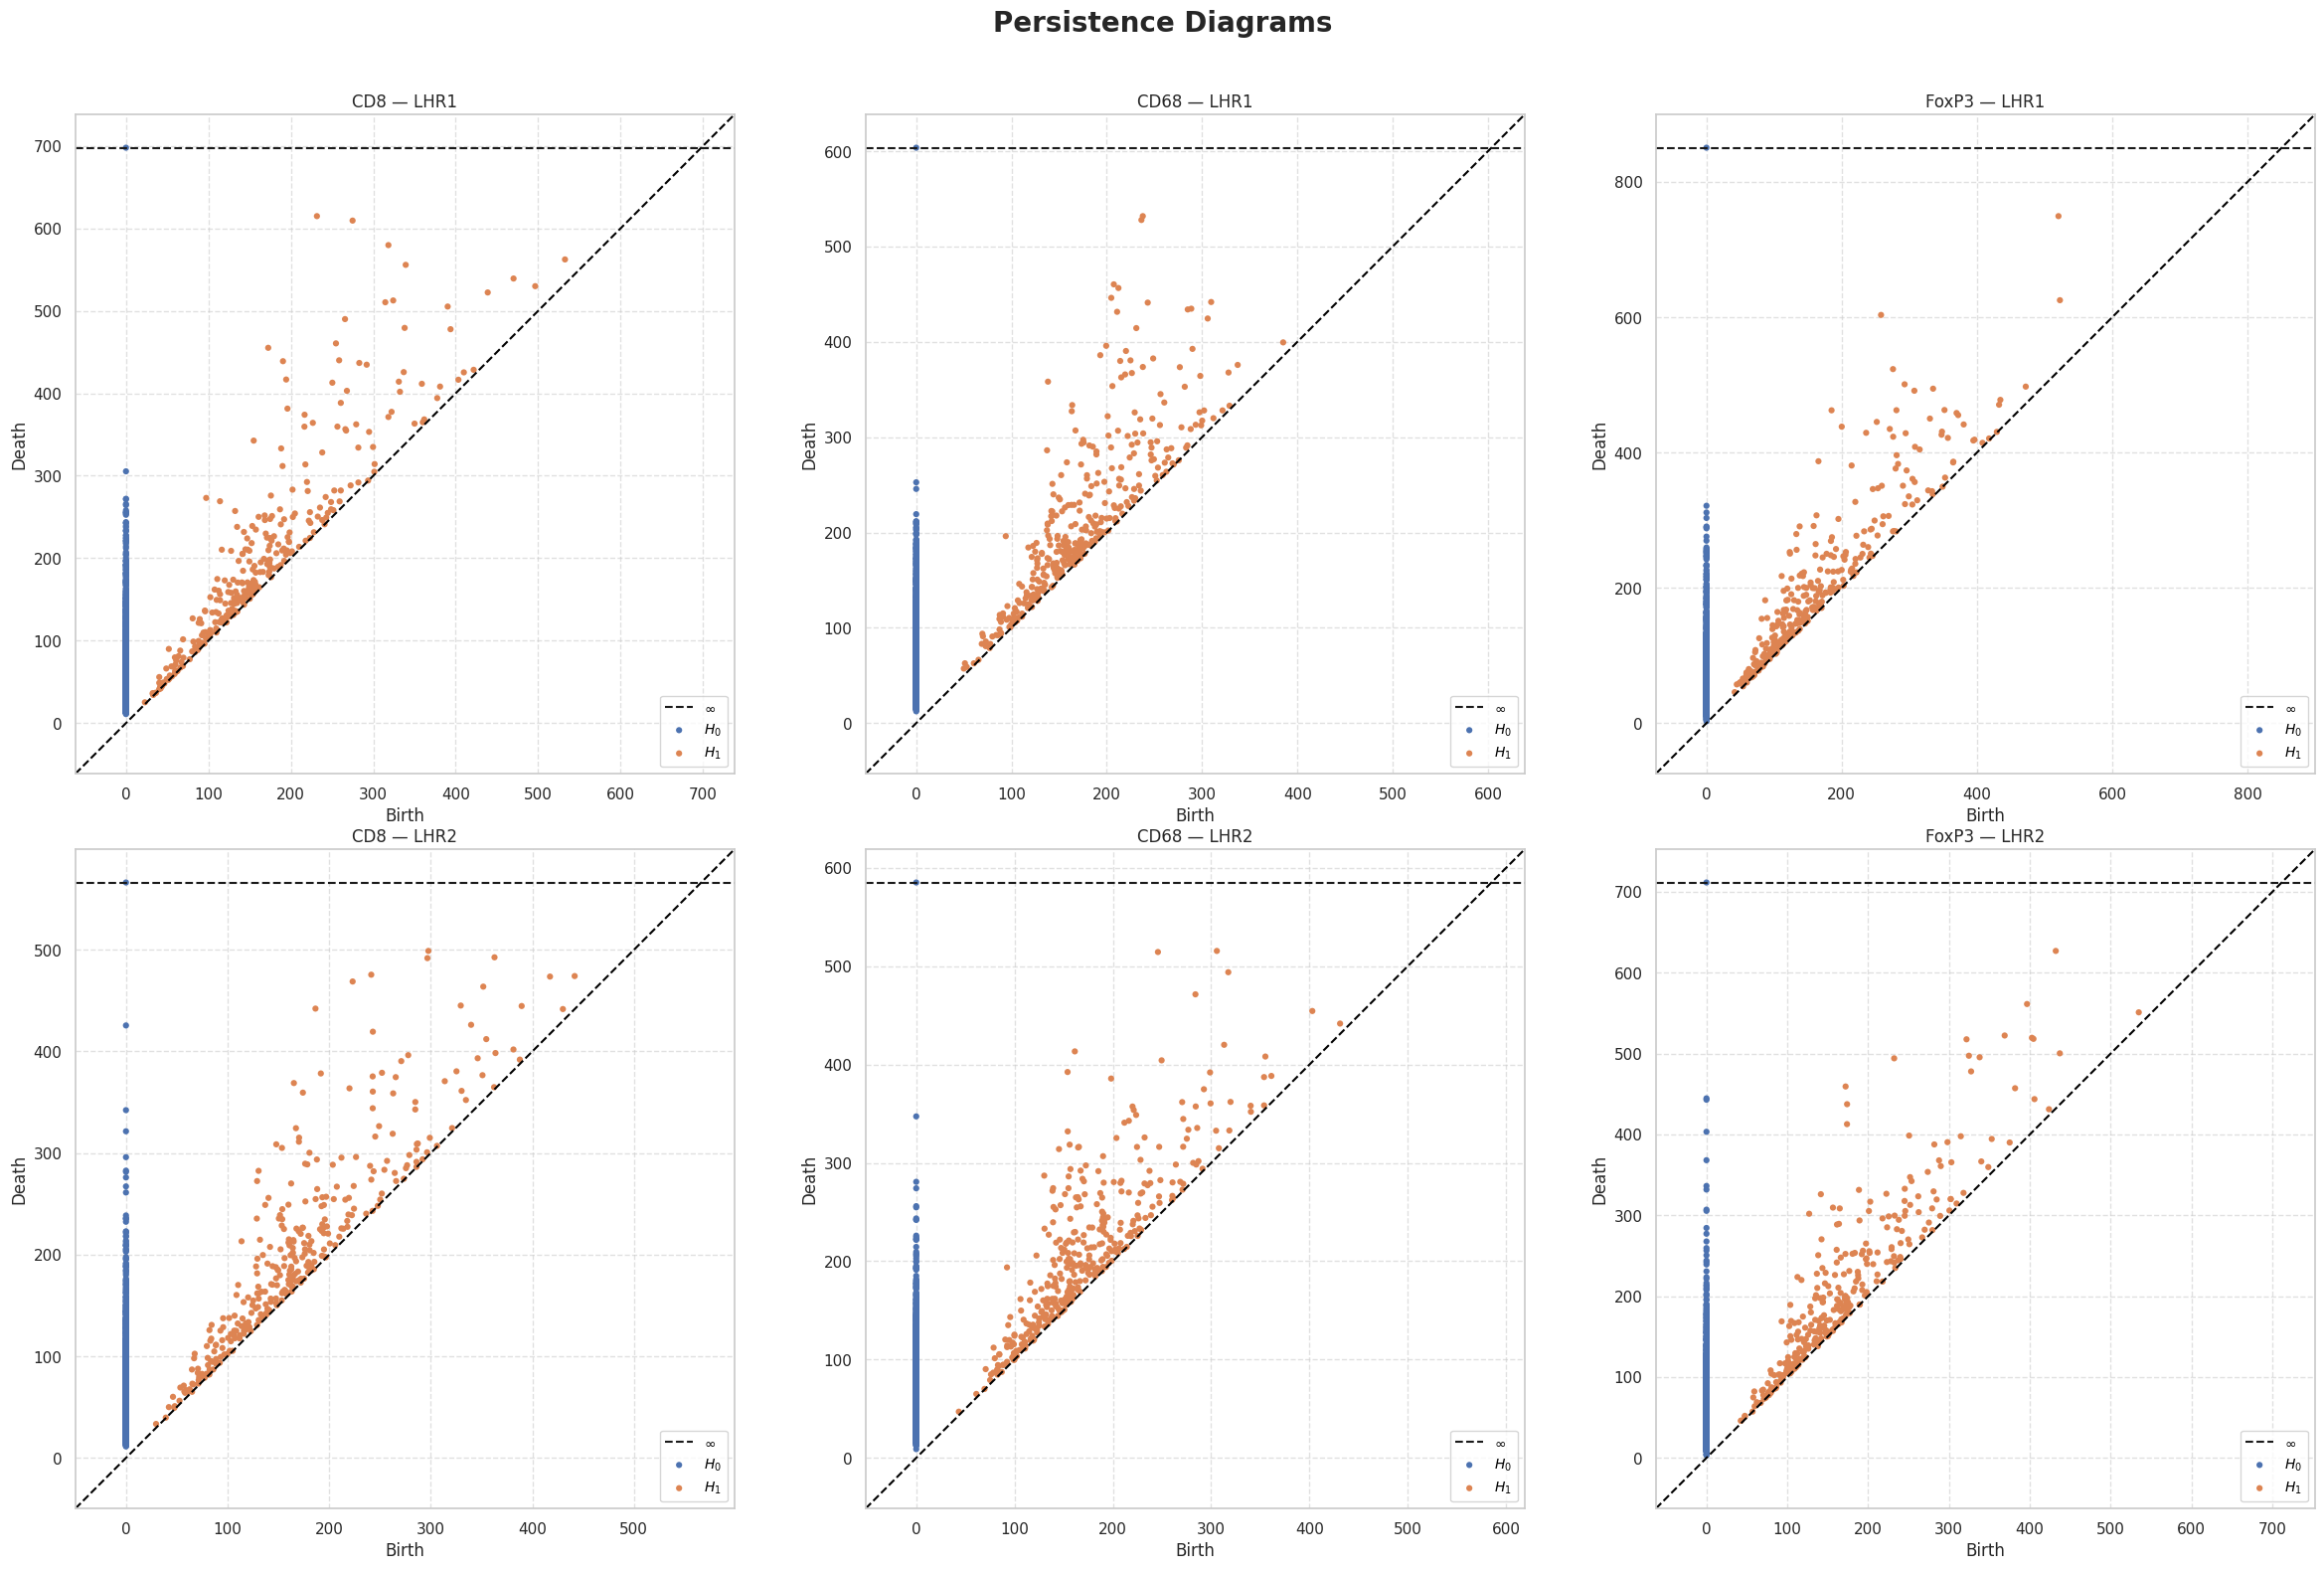

In [8]:
datasets = {
    'CD8': {'LHR1': LHR1, 'LHR2': LHR2},
    'CD68': {'LHR1': LHR1, 'LHR2': LHR2},
    'FoxP3': {'LHR1': LHR1, 'LHR2': LHR2},
}

all_diagrams = {}
for celltype in ['CD8', 'CD68', 'FoxP3']:
    for label, df in [('LHR1', LHR1), ('LHR2', LHR2)]:
        data = df[df['Celltype'] == celltype][['x', 'y']].values
        np.random.shuffle(data)
        data = data[:1500]
        print(f"Calculating {celltype} {label}: {len(data)} points...")
        result = ripser.ripser(data, maxdim=1)
        all_diagrams[(celltype, label)] = result['dgms']

# Store in named variables for downstream cells
diagrams_CD8_1 = all_diagrams[('CD8', 'LHR1')]
diagrams_CD68_1 = all_diagrams[('CD68', 'LHR1')]
diagrams_Fox_1 = all_diagrams[('FoxP3', 'LHR1')]
diagrams_CD8_2 = all_diagrams[('CD8', 'LHR2')]
diagrams_CD68_2 = all_diagrams[('CD68', 'LHR2')]
diagrams_Fox_2 = all_diagrams[('FoxP3', 'LHR2')]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Persistence Diagrams', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        persim.plot_diagrams(all_diagrams[(celltype, label)], show=False,
                             title=f"{celltype} — {label}",
                             labels=['$H_0$', '$H_1$'], ax=ax)
        ax.set_xlabel("Birth", fontsize=12)
        ax.set_ylabel("Death", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])

### Observations

**$H_0$ — connectivity:** Across all cell types and both regions, the $H_0$ points cluster near the diagonal, meaning connected components merge quickly as the scale grows. This confirms that the immune cells form a single, densely connected spatial distribution rather than isolated clusters.

**$H_1$ — loops in CD8 and CD68:** Both CD8 and CD68 diagrams exhibit numerous $H_1$ features, many with moderate to high persistence (far from the diagonal). This indicates the presence of significant circular voids in their spatial distribution — consistent with the immune exclusion zones observed in the spatial maps (areas around necrotic/hypoxic cores where these cells are absent).

**$H_1$ — loops in FoxP3:** The FoxP3 diagrams show fewer and generally less persistent $H_1$ features. This is expected since FoxP3 cells, being co-localized with hypoxic zones, fill in some of the voids that CD8 and CD68 cells avoid. Their spatial distribution is more homogeneous, with fewer "holes".

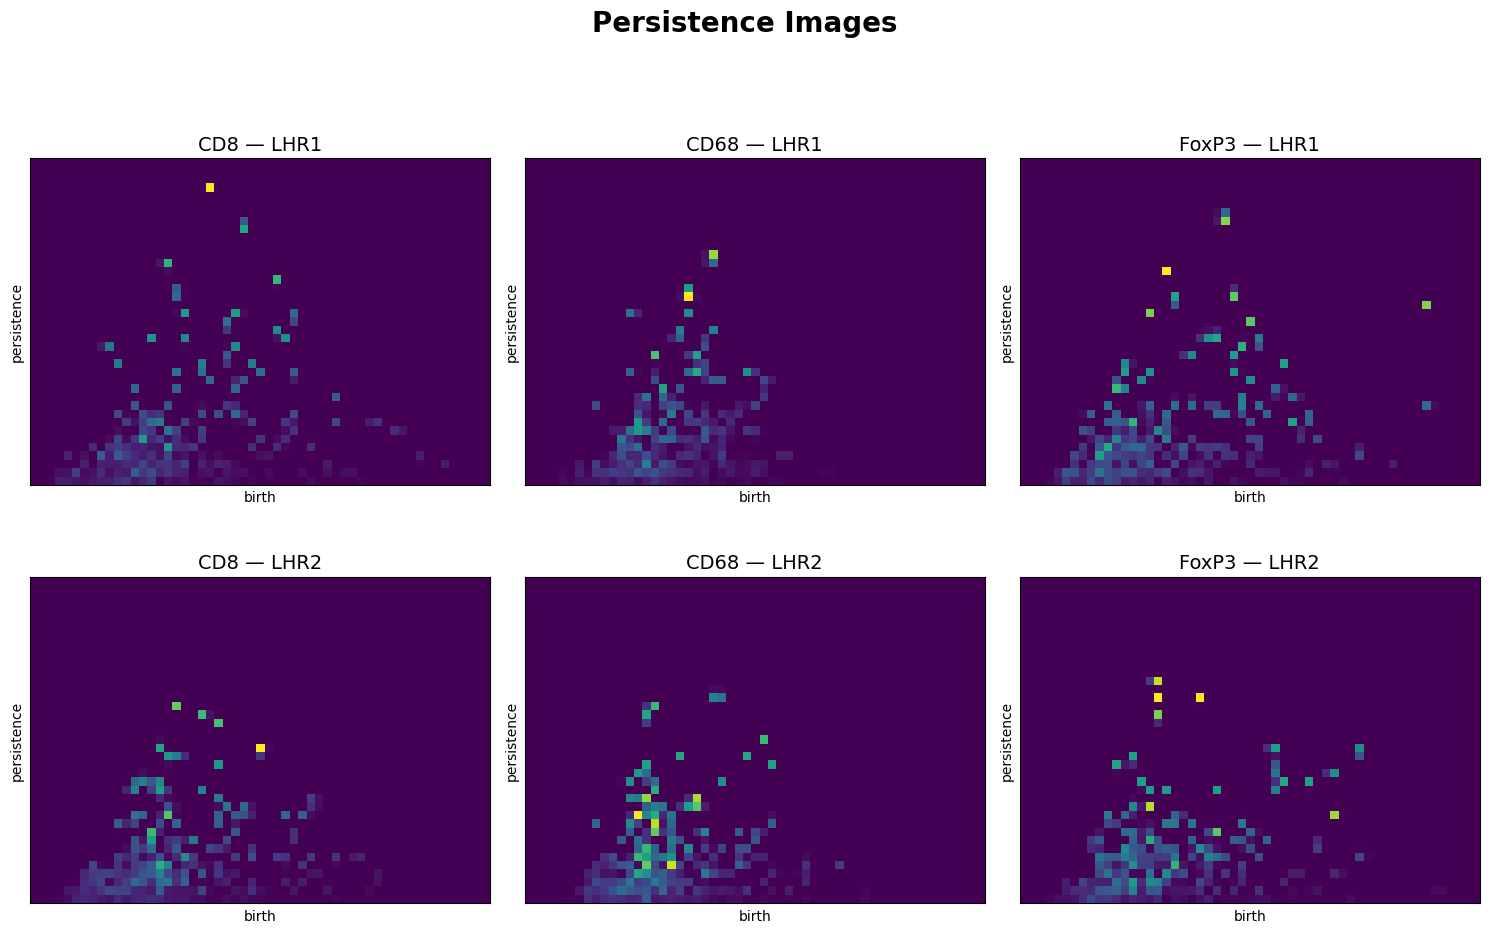

In [9]:
all_diagrams_list = [diagrams_CD8_1, diagrams_CD68_1, diagrams_Fox_1, diagrams_CD8_2, diagrams_CD68_2, diagrams_Fox_2]

all_births = [np.max(d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
all_pers = [np.max(d[1][:, 1] - d[1][:, 0]) for d in all_diagrams_list if d[1].size > 0]
global_max_birth = max(all_births)
global_max_pers = max(all_pers)

pimgr = PersistenceImager(
    pixel_size=global_max_birth / 50,
    birth_range=(0, global_max_birth * 1.1),
    pers_range=(0, global_max_pers * 1.1),
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Persistence Images', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        dgm = all_diagrams_list[row * 3 + col]
        img = pimgr.transform(dgm[1])
        pimgr.plot_image(img, ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

### Vectorizations

To move from visual inspection to quantitative comparison, we transform the persistence diagrams into fixed-size vector representations:

- **Persistence Images:** Each diagram is converted into a 2D image by placing a Gaussian kernel on each point in the birth-persistence plane. This produces a stable, differentiable summary that can be used as input for machine learning models or statistical tests. Bright regions indicate where topological features concentrate.

- **Persistence Landscapes:** Each diagram is converted into a sequence of piecewise-linear functions (one per "depth level"). The first landscape captures the most persistent features, the second captures the next most persistent, etc. Landscapes live in a Banach space, which allows computing means, norms, and statistical tests directly.

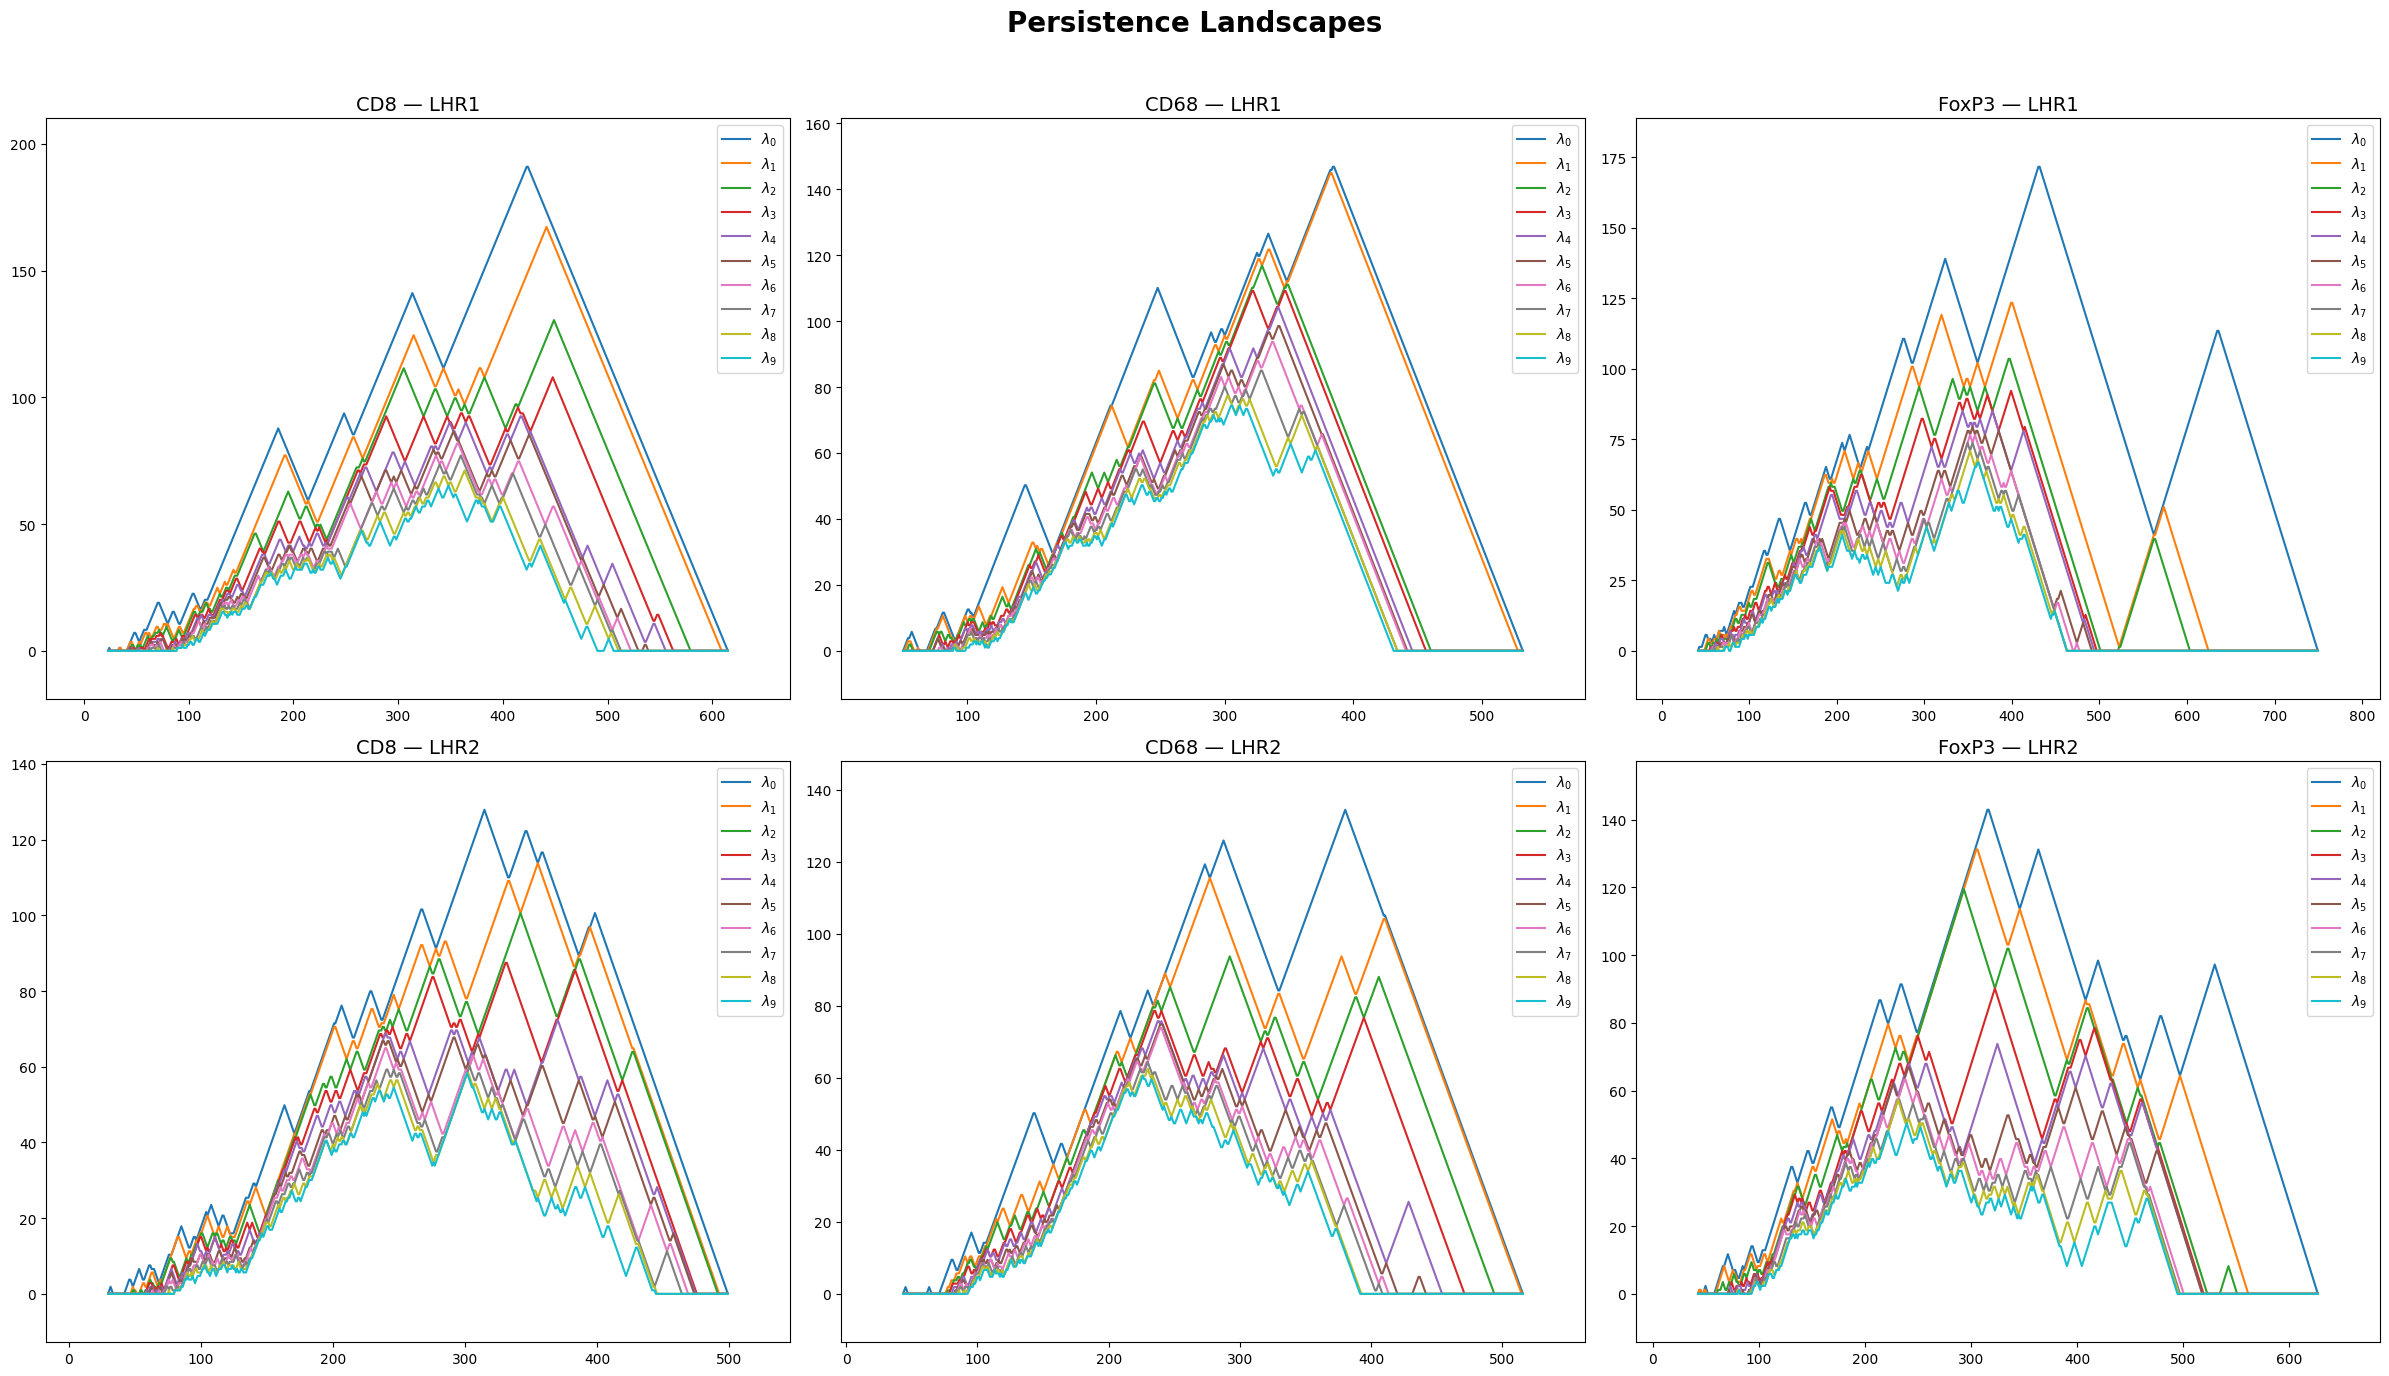

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Persistence Landscapes', fontsize=20, fontweight='bold')

celltypes = ['CD8', 'CD68', 'FoxP3']
labels = ['LHR1', 'LHR2']
diagrams_map = {
    ('CD8', 'LHR1'): diagrams_CD8_1, ('CD68', 'LHR1'): diagrams_CD68_1, ('FoxP3', 'LHR1'): diagrams_Fox_1,
    ('CD8', 'LHR2'): diagrams_CD8_2, ('CD68', 'LHR2'): diagrams_CD68_2, ('FoxP3', 'LHR2'): diagrams_Fox_2,
}

for row, label in enumerate(labels):
    for col, celltype in enumerate(celltypes):
        ax = axes[row, col]
        pla = PersLandscapeApprox(dgms=diagrams_map[(celltype, label)], hom_deg=1)
        plot_landscape_simple(pla, depth_range=range(10), ax=ax)
        ax.set_title(f"{celltype} — {label}", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Part II — TDA-Based Classification of Immune Cell Spatial Patterns

In Part I, we observed qualitative differences in how CD8, CD68 and FoxP3 cells organize spatially within the tumor. We now ask: **can we automatically distinguish immune cell types based solely on the topology of their spatial distribution?**

To answer this, we use the dataset of **1.5mm x 1.5mm tumor regions** from Vipond et al. (2021), which contains ~535 regions per cell type across multiple tumors. For each region, we:

1. **Compute persistent homology** with a 1-parameter Vietoris-Rips filtration
2. **Store the ROI-level $H_0$ and $H_1$ persistence diagrams**
3. **Convert the diagrams into one-parameter persistence landscapes**
4. **Classify** cell types with regularized LDA under grouped tumor-level splits

This part is therefore fully based on the **one-parameter landscape pipeline** used throughout the rest of the notebook.


## 1. Loading the 1.5mm Regions dataset

The dataset comes from Vipond et al. (2021) and consists of immunohistochemistry (IHC) images of head and neck squamous cell carcinoma specimens, segmented into non-overlapping **1.5mm x 1.5mm** regions of interest (ROIs).

Each CSV file contains the **(x, y) coordinates** of all cells of a single type detected in one ROI. There is no hypoxia marker here — just spatial positions. The data spans **~12 different tumors** (T_A through T_P), with multiple ROIs per tumor.

We recover the **tumor identifier** directly from the filename and keep it throughout the pipeline. This allows us to evaluate the classifiers with **grouped train/test splits at the tumor level**, rather than mixing ROIs from the same tumor across train and test.

We also filter out regions with fewer than 20 cells, as these are too sparse to produce meaningful topological features.

In [11]:
import os
import glob
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

base_path = "1.5mmRegions"
celltypes = ['CD8', 'FoxP3', 'CD68']
GLOBAL_SEED = 42
rng_global = np.random.default_rng(GLOBAL_SEED)


def extract_tumor_id(filepath):
    """Extract the tumor identifier from filenames such as T_I_ROI_12_locations_CD8.csv."""
    return Path(filepath).name.split('_ROI_')[0]


regions = {}
for ct in celltypes:
    folder = os.path.join(base_path, ct)
    files = sorted(glob.glob(os.path.join(folder, "*.csv")))
    regions[ct] = []
    for f in files:
        df = pd.read_csv(f)
        if len(df) >= 20:
            regions[ct].append({
                'points': df[['x', 'y']].values,
                'tumor_id': extract_tumor_id(f),
                'filename': Path(f).name,
            })

for ct in celltypes:
    tumor_ids = sorted({region['tumor_id'] for region in regions[ct]})
    print(f"{ct}: {len(regions[ct])} regions loaded across {len(tumor_ids)} tumors")

CD8: 530 regions loaded across 16 tumors
FoxP3: 502 regions loaded across 16 tumors
CD68: 549 regions loaded across 16 tumors


## 2. Computing persistence diagrams for all regions

For each region, we compute the **Vietoris-Rips persistent homology** up to dimension 1 using `ripser`. This means we track:
- **$H_0$**: how connected components merge as the distance threshold grows
- **$H_1$**: how loops (circular voids) appear and disappear

The output is a **persistence diagram**: a set of (birth, death) pairs, where each pair represents a topological feature that appears at the "birth" scale and disappears at the "death" scale. A point far from the diagonal corresponds to a **persistent** (significant) feature; a point near the diagonal is often interpreted as topological noise.

To keep computation tractable (~1600 regions), we subsample large point clouds to 500 points. The Rips complex has $O(n^3)$ complexity, so this is a necessary trade-off. Here the subsampling is made **reproducible** by fixing the random seed and by storing the exact point subset used for each region.

In [12]:
MAX_POINTS = 500


def subsample_points(pts, max_points, seed_offset=0):
    """Subsample a point cloud reproducibly when it exceeds max_points."""
    if len(pts) <= max_points:
        return pts.copy()
    rng_local = np.random.default_rng(GLOBAL_SEED + seed_offset)
    idx = rng_local.choice(len(pts), max_points, replace=False)
    return pts[idx]


diagrams_by_type = {}
region_metadata = []
for ct in celltypes:
    diagrams_by_type[ct] = []
    for i, region in enumerate(regions[ct]):
        pts_sub = subsample_points(region['points'], MAX_POINTS, seed_offset=i)
        result = ripser.ripser(pts_sub, maxdim=1)
        diagrams_by_type[ct].append(result['dgms'])
        region_metadata.append({
            'celltype': ct,
            'tumor_id': region['tumor_id'],
            'filename': region['filename'],
            'n_points_original': len(region['points']),
            'n_points_used': len(pts_sub),
        })
        if (i + 1) % 100 == 0:
            print(f"  {ct}: {i + 1}/{len(regions[ct])} done")
    print(f"{ct}: {len(diagrams_by_type[ct])} diagrams computed")

  CD8: 100/530 done
  CD8: 200/530 done
  CD8: 300/530 done
  CD8: 400/530 done
  CD8: 500/530 done
CD8: 530 diagrams computed
  FoxP3: 100/502 done
  FoxP3: 200/502 done
  FoxP3: 300/502 done
  FoxP3: 400/502 done
  FoxP3: 500/502 done
FoxP3: 502 diagrams computed
  CD68: 100/549 done
  CD68: 200/549 done
  CD68: 300/549 done
  CD68: 400/549 done
  CD68: 500/549 done
CD68: 549 diagrams computed


## 3. Assembling ROI-level records

Persistence diagrams are variable-size sets of points, so the first step is to store them in a clean ROI-level table that we can reuse throughout the notebook.

At this stage we only assemble, for each ROI:
- its metadata (`celltype`, `tumor_id`, `filename`)
- the raw point cloud
- the finite $H_0$ persistence pairs
- the $H_1$ persistence pairs

The actual vectorization is done later inside the landscape pipeline. Keeping the raw diagrams separate from the classifier makes it easier to avoid train/test leakage and to swap representations cleanly.


In [13]:
def finite_h0(dgm):
    """Remove the single infinite H0 point before vectorization."""
    return dgm[0][np.isfinite(dgm[0][:, 1])]



def build_roi_records(regions_by_type, diagrams_lookup):
    records = []
    for ct in celltypes:
        for region, dgm in zip(regions_by_type[ct], diagrams_lookup[ct]):
            records.append({
                'celltype': ct,
                'tumor_id': region['tumor_id'],
                'filename': region['filename'],
                'points': region['points'],
                'diagram_h0': finite_h0(dgm),
                'diagram_h1': dgm[1],
            })
    return records


roi_records = build_roi_records(regions, diagrams_by_type)

y = np.array([record['celltype'] for record in roi_records])
groups = np.array([record['tumor_id'] for record in roi_records])
filenames = np.array([record['filename'] for record in roi_records])

print(f"Number of ROIs: {len(roi_records)}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Number of tumor groups: {len(np.unique(groups))}")


Number of ROIs: 1581
Class distribution: {np.str_('CD68'): np.int64(549), np.str_('CD8'): np.int64(530), np.str_('FoxP3'): np.int64(502)}
Number of tumor groups: 16


## 4. ROI-level dataset summary

Before fitting the classifier, we inspect the size of the dataset after the 500-point subsampling used for the baseline diagrams.

This summary is descriptive only. Its goal is to show:
- how many ROIs are available per cell type
- how many distinct tumors contribute to each class
- how strong the point-cloud subsampling is on average

This is more informative here than a persistence-image PCA because the rest of Part II now uses a landscape-only pipeline.


In [14]:
df_roi_summary = (
    pd.DataFrame(region_metadata)
    .groupby('celltype')
    .agg(
        n_rois=('filename', 'size'),
        n_tumors=('tumor_id', 'nunique'),
        mean_points_original=('n_points_original', 'mean'),
        mean_points_used=('n_points_used', 'mean'),
        share_subsampled=('n_points_original', lambda s: np.mean(s > MAX_POINTS)),
    )
    .sort_index()
)

df_roi_summary.style.format({
    'mean_points_original': '{:.1f}',
    'mean_points_used': '{:.1f}',
    'share_subsampled': '{:.1%}',
}).set_caption(
    'ROI-level summary of the 500-point baseline dataset used in the one-parameter landscape experiments.'
)


,n_rois,n_tumors,mean_points_original,mean_points_used,share_subsampled
celltype,,,,,
CD68,549,16,749.3,451.9,74.9%
CD8,530,16,1058.6,441.9,74.0%
FoxP3,502,16,464.5,310.5,33.9%


## 5. Classification with one-parameter persistence landscapes

To follow more closely the methodology of Vipond et al. (2021) while remaining in **one-parameter persistent homology**, we use **persistence landscapes** built from the ROI-level persistence diagrams.

Our baseline uses:
- the **first $H_1$ persistence landscape** only
- point clouds subsampled to **500 points**
- a **regularized LDA classifier** on the resulting landscape vectors

### What is the landscape grid?
A persistence landscape is a function of the radius parameter. To feed it into a classifier, we sample that function on a finite grid of radius values.

Concretely, the grid is:
- `start = 0`
- `stop = 1.05 x max(death)` on the **training diagrams only**
- `num_steps = 80`

So the grid is just the set of 80 radius values where the landscape is evaluated. We do **not** choose one global grid using the full dataset, because that would leak information from the test tumors into the representation.

### Why this section can be slow
There are two expensive parts in the notebook:
1. computing `ripser` diagrams, especially at **1000 points**
2. repeating grouped train/test evaluation many times

The Rips computation is the true bottleneck: its cost grows very quickly with the number of points, so going from 500 to 1000 points is much more expensive than a simple x2.

The code below uses a faster direct formula for the **first** persistence landscape, which makes the vectorization step substantially lighter than the generic `PersLandscapeApprox` route.

**Evaluation protocol:** For each task, we repeat grouped **80/20 train-test splits** at the tumor level using `GroupShuffleSplit`. All ROIs from a tumor stay entirely in train or entirely in test.

We test 4 tasks:
- 3 **pairwise** comparisons: CD8 vs FoxP3, CD8 vs CD68, FoxP3 vs CD68
- 1 **three-way** classification: CD8 vs FoxP3 vs CD68

A random baseline would give **50%** for pairwise and **33%** for three-way. Because the split is done at the tumor level, these accuracies target generalization to **unseen tumors** rather than to unseen ROIs from already-seen tumors.


In [15]:
from contextlib import redirect_stdout
from io import StringIO
from itertools import combinations
from numpy.linalg import LinAlgError

N_SPLITS = 30
TEST_SIZE = 0.2
LANDSCAPE_DEPTH = 1
LANDSCAPE_NUM_STEPS = 80
CLASSIFIER_NAME = 'Regularized LDA'


def make_lda_classifier():
    """Regularized LDA, matching the spirit of Vipond et al. (2021)."""
    return LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')


def get_classification_tasks():
    tasks = list(combinations(celltypes, 2)) + [tuple(celltypes)]
    task_labels = [f"{a} vs {b}" for a, b in combinations(celltypes, 2)] + ['3-way']
    return tasks, task_labels


def sanitize_diagram(dgm):
    """Coerce a persistence diagram to a finite ``(n, 2)`` float array."""
    try:
        arr = np.asarray(dgm, dtype=float)
    except (TypeError, ValueError):
        return np.empty((0, 2), dtype=float)

    if arr.size == 0:
        return np.empty((0, 2), dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        return np.empty((0, 2), dtype=float)

    arr = arr[np.all(np.isfinite(arr), axis=1)]
    if arr.size == 0:
        return np.empty((0, 2), dtype=float)
    return arr


def make_landscape_input(dgm, hom_deg):
    if hom_deg == 0:
        return [dgm]
    return [np.empty((0, 2)), dgm]


def build_landscape_grid(diagrams, hom_deg, num_steps=LANDSCAPE_NUM_STEPS, depth=LANDSCAPE_DEPTH):
    """Fit a 1-parameter persistence-landscape grid on the training diagrams only."""
    clean_diagrams = [sanitize_diagram(d) for d in diagrams]
    non_empty = [d for d in clean_diagrams if d.size > 0]
    if not non_empty:
        raise ValueError(f"Training split contains no non-empty H{hom_deg} diagrams.")

    stop = max(np.max(d[:, 1]) for d in non_empty)
    stop = max(1e-6, 1.05 * float(stop))

    return {
        'hom_deg': hom_deg,
        'start': 0.0,
        'stop': stop,
        'num_steps': num_steps,
        'depth': depth,
        'xs': np.linspace(0.0, stop, num_steps),
    }


def landscape_x_values(grid):
    return grid.get('xs', np.linspace(grid['start'], grid['stop'], grid['num_steps']))


def quiet_pers_landscape_approx(*args, **kwargs):
    """Silence Persim's noisy 'Bad choice of grid' prints."""
    with redirect_stdout(StringIO()):
        return PersLandscapeApprox(*args, **kwargs)


def first_landscape_values(dgm, xs):
    """Fast direct computation of the first persistence landscape on a fixed grid."""
    if dgm.size == 0:
        return np.zeros_like(xs)

    births = dgm[:, 0][:, None]
    deaths = dgm[:, 1][:, None]
    xs_row = xs[None, :]

    tents = np.minimum(xs_row - births, deaths - xs_row)
    tents = np.maximum(tents, 0.0)
    return tents.max(axis=0) if tents.size else np.zeros_like(xs)


def landscape_array_from_diagram(dgm, grid):
    """Return a zero-padded landscape array of shape (depth, num_steps)."""
    out = np.zeros((grid['depth'], grid['num_steps']))
    dgm = sanitize_diagram(dgm)
    if dgm.size == 0:
        return out

    xs = landscape_x_values(grid)
    if grid['depth'] == 1:
        out[0] = first_landscape_values(dgm, xs)
        return out

    pla = quiet_pers_landscape_approx(
        dgms=make_landscape_input(dgm, grid['hom_deg']),
        hom_deg=grid['hom_deg'],
        start=grid['start'],
        stop=grid['stop'],
        num_steps=grid['num_steps'],
    )

    values = np.asarray(pla.values)
    if values.ndim != 2 or not np.issubdtype(values.dtype, np.number):
        return out

    n_levels = min(grid['depth'], values.shape[0])
    if n_levels > 0:
        out[:n_levels] = values[:n_levels]
    return out


def transform_landscapes(diagrams, grid):
    return np.vstack([landscape_array_from_diagram(dgm, grid).ravel() for dgm in diagrams])


def first_landscape_norm(dgm, grid):
    values = landscape_array_from_diagram(dgm, grid)
    return float(np.linalg.norm(values[0]))


def large_radius_mass(dgm, grid, radius_threshold):
    values = landscape_array_from_diagram(dgm, grid)
    xs = landscape_x_values(grid)
    mask = xs >= radius_threshold
    if not np.any(mask):
        return 0.0
    return float(np.trapezoid(values[0, mask], xs[mask]))


def build_feature_matrix(records, include_h0=False):
    """Build a descriptive feature matrix using landscapes fit on the provided records."""
    h1_diagrams = [record['diagram_h1'] for record in records]
    h1_grid = build_landscape_grid(h1_diagrams, hom_deg=1)
    parts = [transform_landscapes(h1_diagrams, h1_grid)]

    if include_h0:
        h0_diagrams = [record['diagram_h0'] for record in records]
        h0_grid = build_landscape_grid(h0_diagrams, hom_deg=0)
        parts.append(transform_landscapes(h0_diagrams, h0_grid))

    return np.hstack(parts)


def fit_feature_space(train_records, include_h0=False):
    """Fit train-only landscape ranges and return the transformed train matrix."""
    h1_diagrams = [record['diagram_h1'] for record in train_records]
    h1_grid = build_landscape_grid(h1_diagrams, hom_deg=1)
    feature_state = {'h1_grid': h1_grid}
    parts = [transform_landscapes(h1_diagrams, h1_grid)]

    if include_h0:
        h0_diagrams = [record['diagram_h0'] for record in train_records]
        h0_grid = build_landscape_grid(h0_diagrams, hom_deg=0)
        feature_state['h0_grid'] = h0_grid
        parts.append(transform_landscapes(h0_diagrams, h0_grid))

    return np.hstack(parts), feature_state


def transform_feature_space(records, feature_state, include_h0=False):
    parts = [transform_landscapes([record['diagram_h1'] for record in records], feature_state['h1_grid'])]

    if include_h0:
        parts.append(transform_landscapes([record['diagram_h0'] for record in records], feature_state['h0_grid']))

    return np.hstack(parts)


def run_grouped_evaluation(records, feature_configs, n_splits=N_SPLITS, seed=GLOBAL_SEED):
    """Evaluate one or several feature sets with tumor-level splits and train-only landscapes."""
    labels = np.array([record['celltype'] for record in records])
    groups_local = np.array([record['tumor_id'] for record in records])
    tasks, task_labels = get_classification_tasks()

    results = {fs_name: {label: [] for label in task_labels} for fs_name in feature_configs}
    split_stats = {fs_name: {label: 0 for label in task_labels} for fs_name in feature_configs}

    for task, label in zip(tasks, task_labels):
        mask = np.isin(labels, task)
        task_indices = np.where(mask)[0]
        y_task = labels[mask]
        groups_task = groups_local[mask]

        splitter = GroupShuffleSplit(n_splits=n_splits, test_size=TEST_SIZE, random_state=seed)
        for train_idx, test_idx in splitter.split(np.zeros(len(y_task)), y_task, groups_task):
            y_train, y_test = y_task[train_idx], y_task[test_idx]
            if len(np.unique(y_train)) < len(task) or len(np.unique(y_test)) < len(task):
                continue

            train_records = [records[task_indices[i]] for i in train_idx]
            test_records = [records[task_indices[i]] for i in test_idx]

            for fs_name, cfg in feature_configs.items():
                try:
                    X_train, feature_state = fit_feature_space(train_records, **cfg)
                    X_test = transform_feature_space(test_records, feature_state, **cfg)
                    clf = make_lda_classifier()
                    clf.fit(X_train, y_train)
                    score = clf.score(X_test, y_test)
                except (LinAlgError, ValueError, FloatingPointError):
                    continue
                results[fs_name][label].append(score)
                split_stats[fs_name][label] += 1
        print(f"{label} done")

    return task_labels, results, split_stats


def run_grouped_evaluation_multiple_record_sets(feature_sets, n_splits=N_SPLITS, seed=GLOBAL_SEED):
    """Evaluate configurations that rely on different ROI record collections but identical sample ordering."""
    labels_ref = np.array([record['celltype'] for record in roi_records])
    groups_ref = np.array([record['tumor_id'] for record in roi_records])
    tasks, task_labels = get_classification_tasks()

    results = {fs_name: {label: [] for label in task_labels} for fs_name in feature_sets}
    split_stats = {fs_name: {label: 0 for label in task_labels} for fs_name in feature_sets}

    for task, label in zip(tasks, task_labels):
        mask = np.isin(labels_ref, task)
        task_indices = np.where(mask)[0]
        y_task = labels_ref[mask]
        groups_task = groups_ref[mask]

        splitter = GroupShuffleSplit(n_splits=n_splits, test_size=TEST_SIZE, random_state=seed)
        for train_idx, test_idx in splitter.split(np.zeros(len(y_task)), y_task, groups_task):
            y_train, y_test = y_task[train_idx], y_task[test_idx]
            if len(np.unique(y_train)) < len(task) or len(np.unique(y_test)) < len(task):
                continue

            for fs_name, fs_data in feature_sets.items():
                current_records = fs_data['records']
                cfg = fs_data['config']
                train_records = [current_records[task_indices[i]] for i in train_idx]
                test_records = [current_records[task_indices[i]] for i in test_idx]

                try:
                    X_train, feature_state = fit_feature_space(train_records, **cfg)
                    X_test = transform_feature_space(test_records, feature_state, **cfg)
                    clf = make_lda_classifier()
                    clf.fit(X_train, y_train)
                    score = clf.score(X_test, y_test)
                except (LinAlgError, ValueError, FloatingPointError):
                    continue
                results[fs_name][label].append(score)
                split_stats[fs_name][label] += 1
        print(f"{label} done")

    return task_labels, results, split_stats


feature_configs = {
    'H1, 500 pts': {'include_h0': False},
}

task_labels, grouped_results, split_stats = run_grouped_evaluation(roi_records, feature_configs)
results = grouped_results['H1, 500 pts']
base_split_stats = split_stats['H1, 500 pts']

X_h1_ref = build_feature_matrix(roi_records, include_h0=False)
print(f"Landscape feature matrix (H1, 500 pts): {X_h1_ref.shape}")

rows = []
for label in task_labels:
    values = results[label]
    rows.append({
        'Task': label,
        'Mean accuracy': np.mean(values) if values else np.nan,
        'Std accuracy': np.std(values) if values else np.nan,
        'Valid splits': base_split_stats[label],
    })

df_baseline = pd.DataFrame(rows).set_index('Task')
df_baseline.style.format({
    'Mean accuracy': '{:.1%}',
    'Std accuracy': '{:.1%}',
    'Valid splits': '{:d}',
}).set_caption(
    'One-parameter baseline: first H1 persistence landscape at 500 points with repeated grouped 80/20 regularized-LDA evaluation.'
)

CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done
Landscape feature matrix (H1, 500 pts): (1581, 80)


,Mean accuracy,Std accuracy,Valid splits
Task,,,
CD8 vs FoxP3,66.3%,8.1%,30
CD8 vs CD68,54.2%,4.0%,30
FoxP3 vs CD68,70.5%,9.6%,30
3-way,47.5%,5.7%,30


## 6. Confusion matrix (regularized LDA, 3-way)

To better understand the classification errors, we display the **confusion matrix** of the regularized LDA classifier on the 3-way task. Each row represents the true label and each column the predicted label.

For consistency with section 5, the confusion matrix is computed on a **single tumor-level split** and uses the **same train-only landscape construction** as the repeated evaluation: the landscape range is fit on the training tumors only, then applied unchanged to the test tumors.

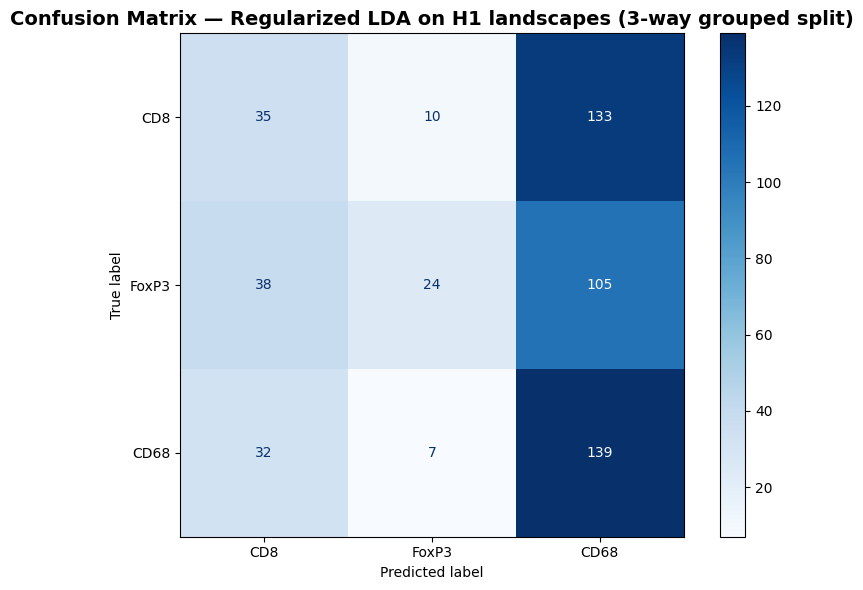

In [16]:
clf_cm = make_lda_classifier()

splitter_cm = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=GLOBAL_SEED)
train_idx, test_idx = next(splitter_cm.split(np.zeros(len(y)), y, groups))

train_records = [roi_records[i] for i in train_idx]
test_records = [roi_records[i] for i in test_idx]
y_train = np.array([record['celltype'] for record in train_records])
y_test = np.array([record['celltype'] for record in test_records])

X_train, feature_state_cm = fit_feature_space(train_records, include_h0=False)
X_test = transform_feature_space(test_records, feature_state_cm, include_h0=False)

clf_cm.fit(X_train, y_train)
y_pred = clf_cm.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=celltypes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=celltypes)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix — Regularized LDA on H1 landscapes (3-way grouped split)', fontsize=14, fontweight='bold')
plt.tight_layout()

### Interpretation of the results

**What carries over from Vipond et al. (2021):** Even in the one-parameter setting, the **landscape vectors** retain enough information to separate some immune-cell types above chance, especially in the pairwise tasks involving FoxP3.

**What remains difficult:** The CD8 vs CD68 comparison is still the hardest. This is consistent with the exploratory analysis: these two populations can occupy spatial arrangements that are closer to one another than either is to FoxP3.

**Why the scores stay below the paper:** Vipond et al. use **multiparameter** landscapes, which add codensity information on top of radius. Here we deliberately stay in **one-parameter homology**, so lower performance is expected even though the downstream methodology is now closer to the paper (landscapes, LDA, repeated 80/20 splits).

**Why the grouped protocol matters:** Because the split is done at the tumor level, these accuracies are stricter than ROI-level random splits and better reflect generalization to **new tumors**.

## 7. Adding $H_0$ to the one-parameter landscape pipeline

The first baseline only uses the **first $H_1$ persistence landscape** at **500 points**. To keep the same one-parameter setting but enrich the topological summary, we now concatenate:

1. the first **$H_1$ landscape**
2. the first **$H_0$ landscape**

This mirrors the logic of the paper, which augments the topological summary rather than adding ad hoc non-topological covariates. Here the role of the enrichment is different from Vipond's codensity parameter because we remain strictly in **one-parameter homology**; the added information comes from combining **connected components** and **loops**.

As before, the landscape range is fit on the **training folds only**, and the downstream classifier remains the same **regularized LDA**.

In [17]:
feature_sets_h0 = {
    'H1, 500 pts': {'include_h0': False},
    'H0 + H1, 500 pts': {'include_h0': True},
}

task_labels_h0, results_h0, split_stats_h0 = run_grouped_evaluation(roi_records, feature_sets_h0)

X_h1_500_ref = build_feature_matrix(roi_records, include_h0=False)
X_h0h1_500_ref = build_feature_matrix(roi_records, include_h0=True)
print(f"Reference H1 landscape matrix (500 pts):      {X_h1_500_ref.shape}")
print(f"Reference H0 + H1 landscape matrix (500 pts): {X_h0h1_500_ref.shape}")

rows = []
for label in task_labels_h0:
    m_h1 = np.mean(results_h0['H1, 500 pts'][label]) if results_h0['H1, 500 pts'][label] else np.nan
    s_h1 = np.std(results_h0['H1, 500 pts'][label]) if results_h0['H1, 500 pts'][label] else np.nan
    m_h0h1 = np.mean(results_h0['H0 + H1, 500 pts'][label]) if results_h0['H0 + H1, 500 pts'][label] else np.nan
    s_h0h1 = np.std(results_h0['H0 + H1, 500 pts'][label]) if results_h0['H0 + H1, 500 pts'][label] else np.nan
    rows.append({
        'Task': label,
        'H1, 500 pts': f"{m_h1:.1%} ± {s_h1:.1%} ({split_stats_h0['H1, 500 pts'][label]:02d})",
        'H0 + H1, 500 pts': f"{m_h0h1:.1%} ± {s_h0h1:.1%} ({split_stats_h0['H0 + H1, 500 pts'][label]:02d})",
    })

df_h0 = pd.DataFrame(rows).set_index('Task')
df_h0.style.set_caption(
    'Effect of adding the first H0 landscape to the first H1 landscape at 500 points. Values are mean ± sd accuracy over grouped 80/20 splits (valid splits in parentheses).'
)

CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done
Reference H1 landscape matrix (500 pts):      (1581, 80)
Reference H0 + H1 landscape matrix (500 pts): (1581, 160)


,"H1, 500 pts","H0 + H1, 500 pts"
Task,,
CD8 vs FoxP3,66.3% ± 8.1% (30),65.8% ± 8.0% (30)
CD8 vs CD68,54.2% ± 4.0% (30),54.9% ± 5.9% (30)
FoxP3 vs CD68,70.5% ± 9.6% (30),71.0% ± 9.4% (30)
3-way,47.5% ± 5.7% (30),48.0% ± 6.0% (30)


Adding the first **$H_0$ landscape** to the first **$H_1$ landscape** enriches the representation in a purely topological way: we now combine information on **connected components** and **loops**.

If the gain is visible, it means that merger structure complements loop structure. If the gain stays small, that is also informative: it suggests that the dominant discriminative signal is still carried mostly by $H_1$.


### 7.2 Descriptive LDA projection of the $H_0 + H_1$ landscape vectors

Vipond et al. use **LDA as a low-dimensional view** of the landscape vectors in addition to using LDA as a classifier. We reproduce that idea here in the one-parameter setting.

The plot below is **descriptive only**: it is fit on the full dataset and is not used to estimate predictive performance. Its purpose is simply to visualize whether adding $H_0$ changes the geometry of the classes in feature space.

Reference H0 + H1 landscape matrix (500 pts): (1581, 160)


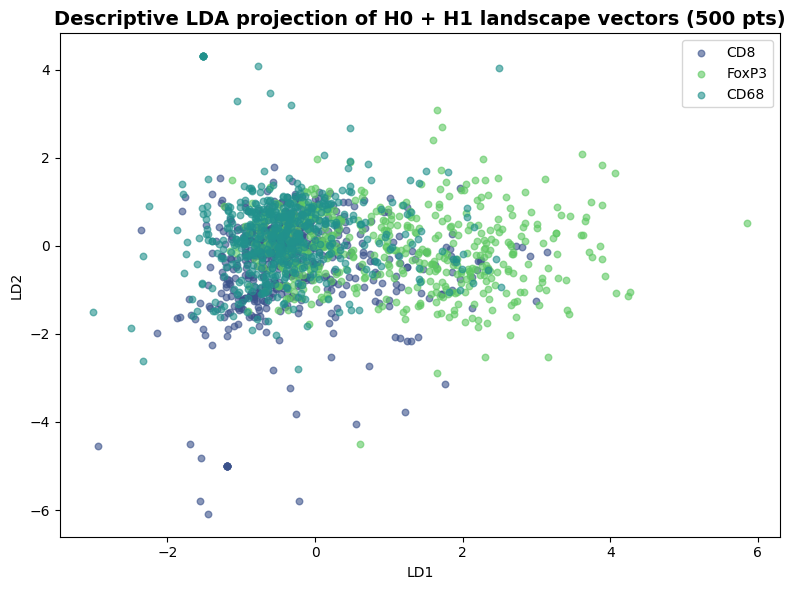

In [18]:
X_h0h1_500_ref = build_feature_matrix(roi_records, include_h0=True)
print(f"Reference H0 + H1 landscape matrix (500 pts): {X_h0h1_500_ref.shape}")

lda_projection = LinearDiscriminantAnalysis(n_components=2)
X_lda_proj = lda_projection.fit_transform(X_h0h1_500_ref, y)

palette = {'CD8': '#3b528b', 'CD68': '#21918c', 'FoxP3': '#5ec962'}
fig, ax = plt.subplots(figsize=(8, 6))
for ct in celltypes:
    mask = y == ct
    ax.scatter(X_lda_proj[mask, 0], X_lda_proj[mask, 1], label=ct, alpha=0.6, s=22, color=palette[ct])

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_title('Descriptive LDA projection of H0 + H1 landscape vectors (500 pts)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()

The descriptive LDA view shows whether the additional $H_0$ information changes the linear separation between the three cell types. This does **not** replace the grouped train/test evaluation above, but it is useful for matching the way Vipond et al. visually interrogate the landscape vectors.

If the class clouds remain mixed in this 2D projection, that does not invalidate the method; it simply means that the separation is limited even after adding component information.

## 8. Increasing the subsampling rate after adding $H_0$

The next step keeps the same topological feature set ($H_0 + H_1$ landscapes) while increasing the subsampling rate from **500** to **1000** points.

This is the slowest section of the notebook for two distinct reasons:
1. `ripser` must rebuild the persistence diagrams on much larger point clouds
2. the grouped evaluation is then rerun on the new diagrams

The first cost dominates. In practice, Rips complexes scale very poorly with the number of points, so **1000 points can be several times slower than 500**, not just twice as slow.

To make reruns less painful, the code below reuses the 1000-point diagrams if they are already present in memory, and the landscape vectorization itself now uses a fast direct formula for the first landscape.


In [19]:
import time as _time

MAX_POINTS_NEW = 1000

if 'roi_records_1000' in globals():
    print(f"Using cached {MAX_POINTS_NEW}-point ROI records already in memory.")
else:
    print(f"Recomputing persistence diagrams with MAX_POINTS = {MAX_POINTS_NEW}...")
    t0 = _time.time()

    diagrams_by_type_1000 = {}
    for ct in celltypes:
        diagrams_by_type_1000[ct] = []
        for i, region in enumerate(regions[ct]):
            pts_sub = subsample_points(region['points'], MAX_POINTS_NEW, seed_offset=10000 + i)
            result = ripser.ripser(pts_sub, maxdim=1)
            diagrams_by_type_1000[ct].append(result['dgms'])
            if (i + 1) % 100 == 0:
                print(f"  {ct}: {i + 1}/{len(regions[ct])} done")
        print(f"{ct}: {len(diagrams_by_type_1000[ct])} diagrams computed")

    print()
    print(f"Diagram recomputation time: {_time.time() - t0:.1f} seconds")
    roi_records_1000 = build_roi_records(regions, diagrams_by_type_1000)

X_h0h1_1000_ref = build_feature_matrix(roi_records_1000, include_h0=True)
print(f"Reference H0 + H1 landscape matrix (1000 pts): {X_h0h1_1000_ref.shape}")

feature_sets_sub = {
    'H0 + H1, 500 pts': {'records': roi_records, 'config': {'include_h0': True}},
    'H0 + H1, 1000 pts': {'records': roi_records_1000, 'config': {'include_h0': True}},
}

t_eval = _time.time()
task_labels_sub, results_sub, split_stats_sub = run_grouped_evaluation_multiple_record_sets(feature_sets_sub)
print(f"Evaluation time: {_time.time() - t_eval:.1f} seconds")

rows = []
for label in task_labels_sub:
    m5 = np.mean(results_sub['H0 + H1, 500 pts'][label]) if results_sub['H0 + H1, 500 pts'][label] else np.nan
    s5 = np.std(results_sub['H0 + H1, 500 pts'][label]) if results_sub['H0 + H1, 500 pts'][label] else np.nan
    m10 = np.mean(results_sub['H0 + H1, 1000 pts'][label]) if results_sub['H0 + H1, 1000 pts'][label] else np.nan
    s10 = np.std(results_sub['H0 + H1, 1000 pts'][label]) if results_sub['H0 + H1, 1000 pts'][label] else np.nan
    rows.append({
        'Task': label,
        'H0 + H1, 500 pts': f"{m5:.1%} ± {s5:.1%} ({split_stats_sub['H0 + H1, 500 pts'][label]:02d})",
        'H0 + H1, 1000 pts': f"{m10:.1%} ± {s10:.1%} ({split_stats_sub['H0 + H1, 1000 pts'][label]:02d})",
    })

df_sub = pd.DataFrame(rows).set_index('Task')
df_sub.style.set_caption(
    'Effect of increasing the subsampling rate from 500 to 1000 points after adding H0. Values are mean ± sd accuracy over grouped 80/20 splits (valid splits in parentheses).'
)


Recomputing persistence diagrams with MAX_POINTS = 1000...
  CD8: 100/530 done
  CD8: 200/530 done
  CD8: 300/530 done
  CD8: 400/530 done
  CD8: 500/530 done
CD8: 530 diagrams computed
  FoxP3: 100/502 done
  FoxP3: 200/502 done
  FoxP3: 300/502 done
  FoxP3: 400/502 done
  FoxP3: 500/502 done
FoxP3: 502 diagrams computed
  CD68: 100/549 done
  CD68: 200/549 done
  CD68: 300/549 done
  CD68: 400/549 done
  CD68: 500/549 done
CD68: 549 diagrams computed

Diagram recomputation time: 156.3 seconds
Reference H0 + H1 landscape matrix (1000 pts): (1581, 160)
CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done
Evaluation time: 33.4 seconds


,"H0 + H1, 500 pts","H0 + H1, 1000 pts"
Task,,
CD8 vs FoxP3,65.8% ± 8.0% (30),68.8% ± 8.3% (30)
CD8 vs CD68,54.9% ± 5.9% (30),60.8% ± 6.3% (30)
FoxP3 vs CD68,71.0% ± 9.4% (30),70.3% ± 9.4% (30)
3-way,48.0% ± 6.0% (30),52.6% ± 5.1% (30)


### 8.2 Final comparison: $H_1$ at 500 points vs $H_0 + H_1$ at 1000 points

This is the direct end-to-end comparison corresponding to the progression studied in Part II:
- start from **$H_1$ only at 500 points**
- add **$H_0$**
- then increase the subsampling rate to **1000 points**

The goal is to quantify the total gain obtained by moving from the simplest one-parameter landscape pipeline to the richest one considered here, while keeping the same grouped tumor-level evaluation.


In [20]:
print(f"Reference H1 landscape matrix (500 pts):      {X_h1_500_ref.shape}")
print(f"Reference H0 + H1 landscape matrix (1000 pts): {X_h0h1_1000_ref.shape}")

feature_configs_final = {
    'H1, 500 pts': {'records': roi_records, 'config': {'include_h0': False}},
    'H0 + H1, 1000 pts': {'records': roi_records_1000, 'config': {'include_h0': True}},
}

t_final = _time.time()
task_labels_final, all_res, split_stats_final = run_grouped_evaluation_multiple_record_sets(feature_configs_final)
print(f"Final comparison evaluation time: {_time.time() - t_final:.1f} seconds")

rows = []
for label in task_labels_final:
    m_base = np.mean(all_res['H1, 500 pts'][label]) if all_res['H1, 500 pts'][label] else np.nan
    s_base = np.std(all_res['H1, 500 pts'][label]) if all_res['H1, 500 pts'][label] else np.nan
    m_final = np.mean(all_res['H0 + H1, 1000 pts'][label]) if all_res['H0 + H1, 1000 pts'][label] else np.nan
    s_final = np.std(all_res['H0 + H1, 1000 pts'][label]) if all_res['H0 + H1, 1000 pts'][label] else np.nan
    rows.append({
        'Task': label,
        'H1, 500 pts': f"{m_base:.1%} ± {s_base:.1%} ({split_stats_final['H1, 500 pts'][label]:02d})",
        'H0 + H1, 1000 pts': f"{m_final:.1%} ± {s_final:.1%} ({split_stats_final['H0 + H1, 1000 pts'][label]:02d})",
    })

df_final = pd.DataFrame(rows).set_index('Task')
df_final.style.set_caption(
    'Final comparison between the initial one-parameter baseline and the richest one-parameter landscape pipeline considered here. Values are mean ± sd accuracy over grouped 80/20 splits (valid splits in parentheses).'
)


Reference H1 landscape matrix (500 pts):      (1581, 80)
Reference H0 + H1 landscape matrix (1000 pts): (1581, 160)
CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done
Final comparison evaluation time: 23.2 seconds


,"H1, 500 pts","H0 + H1, 1000 pts"
Task,,
CD8 vs FoxP3,66.3% ± 8.1% (30),68.8% ± 8.3% (30)
CD8 vs CD68,54.2% ± 4.0% (30),60.8% ± 6.3% (30)
FoxP3 vs CD68,70.5% ± 9.6% (30),70.3% ± 9.4% (30)
3-way,47.5% ± 5.7% (30),52.6% ± 5.1% (30)


### Interpretation of the results

The final comparison isolates the cumulative effect of the two one-parameter enrichments introduced after the baseline:
1. adding **$H_0$** to the landscape vector
2. increasing the subsampling from **500** to **1000** points

If the richer pipeline performs better, that suggests that both **component information** and **finer point-cloud resolution** matter. If the gain remains limited, then the main missing ingredient relative to Vipond et al. is likely the genuinely **multiparameter** information rather than the downstream classifier.

From a runtime point of view, any gain obtained here must also be weighed against the additional cost of recomputing the 1000-point diagrams.


## 9. Statistical summaries derived from one-parameter landscapes

Vipond et al. do not stop at classification: they also derive **real-valued statistics from the landscapes** and compare their distributions. We now reproduce that logic in the one-parameter setting.

The ROIs are nested within tumors, so the appropriate unit for inference remains the **tumor** rather than the individual ROI.

### 9.1 Tumor-level test on the norm of the first $H_1$ landscape
For each ROI, we compute the **Euclidean norm of the first $H_1$ landscape**. This is the one-parameter analogue of the paper's use of norms of landscape vectors as real-valued summaries of loop structure.

We then average this ROI-level quantity within each **tumor** and **cell type**, yielding one aggregated value per tumor and per cell type. As before, we use a **Friedman test** followed, when appropriate, by paired Wilcoxon signed-rank tests with Bonferroni correction.

Tumors retained for paired inference: 16
Global Friedman test on H1 landscape norms: Statistic = 0.3750, p-value = 8.2903e-01

No significant global differences detected.


/var/folders/zy/ntk0zkvs44qbdbm8dngcdqvh0000gn/T/ipykernel_6974/454056474.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='celltype', y='h1_landscape_norm', palette='viridis', order=['CD8', 'CD68', 'FoxP3'])


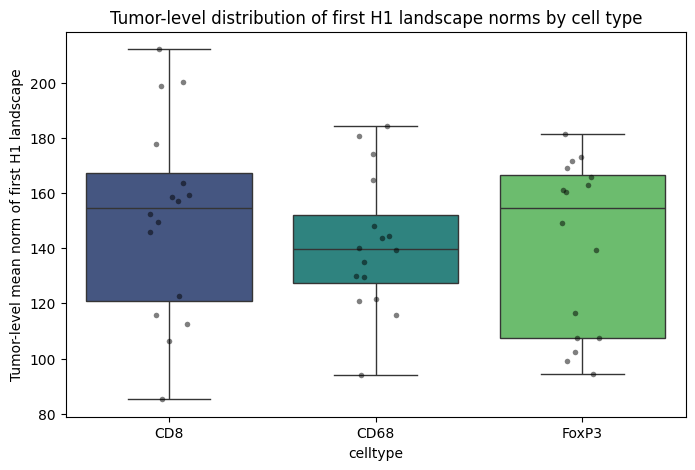

In [21]:
import scipy.stats as stats
from itertools import combinations

h1_grid_stats = build_landscape_grid([record['diagram_h1'] for record in roi_records], hom_deg=1)

for record in roi_records:
    record['h1_landscape_norm'] = first_landscape_norm(record['diagram_h1'], h1_grid_stats)

rows = []
for record in roi_records:
    rows.append({
        'tumor_id': record['tumor_id'],
        'celltype': record['celltype'],
        'h1_landscape_norm': record['h1_landscape_norm'],
    })

df_h1_norm = pd.DataFrame(rows)
tumor_level_norm = (
    df_h1_norm
    .groupby(['tumor_id', 'celltype'], as_index=False)['h1_landscape_norm']
    .mean()
)

tumor_norm_wide = tumor_level_norm.pivot(
    index='tumor_id', columns='celltype', values='h1_landscape_norm'
).dropna()

print(f"Tumors retained for paired inference: {tumor_norm_wide.shape[0]}")

friedman_stat, friedman_p = stats.friedmanchisquare(
    tumor_norm_wide['CD8'],
    tumor_norm_wide['FoxP3'],
    tumor_norm_wide['CD68'],
)
print(f"Global Friedman test on H1 landscape norms: Statistic = {friedman_stat:.4f}, p-value = {friedman_p:.4e}")

if friedman_p < 0.05:
    print("\nSignificant global differences detected. Pairwise Wilcoxon signed-rank tests:")
    alpha_corrected = 0.05 / 3
    for ct1, ct2 in combinations(celltypes, 2):
        stat_w, p_w = stats.wilcoxon(
            tumor_norm_wide[ct1],
            tumor_norm_wide[ct2],
            alternative='two-sided',
            zero_method='wilcox',
        )
        significant = 'Yes' if p_w < alpha_corrected else 'No'
        print(f" - {ct1} vs {ct2}: raw p-value = {p_w:.4e} | Significant (Bonferroni)? {significant}")
else:
    print("\nNo significant global differences detected.")

plot_df = tumor_level_norm.copy()
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='celltype', y='h1_landscape_norm', palette='viridis', order=['CD8', 'CD68', 'FoxP3'])
sns.stripplot(data=plot_df, x='celltype', y='h1_landscape_norm', order=['CD8', 'CD68', 'FoxP3'], color='black', alpha=0.5, size=4)
plt.ylabel('Tumor-level mean norm of first H1 landscape')
plt.title('Tumor-level distribution of first H1 landscape norms by cell type')
plt.show()

### 9.2 Tumor-level test on large-radius landscape mass

A central idea in Vipond et al. is to derive a scalar statistic that emphasizes **large voids**. In the multiparameter paper this is done by integrating the first landscape over a region of the parameter space corresponding to large radii.

In the one-parameter setting, we mimic that idea by integrating the **first $H_1$ landscape above a large-radius threshold**. This yields one ROI-level scalar that specifically measures the contribution of **large loops**. We then average it within each tumor and cell type and again perform tumor-level paired inference.

Large-radius threshold used for the first H1 landscape: 597.65
Tumors retained for paired inference: 16
Global Friedman test on large-radius landscape mass: Statistic = 1.2174, p-value = 5.4406e-01

No significant global differences detected.


/var/folders/zy/ntk0zkvs44qbdbm8dngcdqvh0000gn/T/ipykernel_6974/396162910.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='celltype', y='large_radius_h1_mass', palette='magma', order=['CD8', 'CD68', 'FoxP3'])


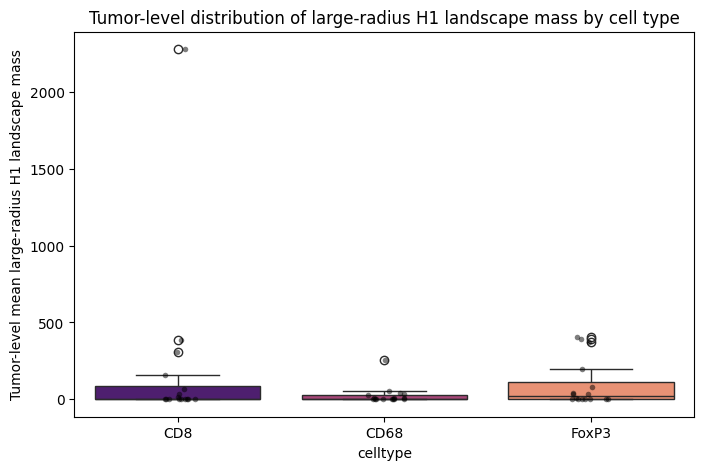

In [22]:
radius_threshold = 0.5 * h1_grid_stats['stop']
print(f"Large-radius threshold used for the first H1 landscape: {radius_threshold:.2f}")

for record in roi_records:
    record['large_radius_h1_mass'] = large_radius_mass(record['diagram_h1'], h1_grid_stats, radius_threshold)

rows = []
for record in roi_records:
    rows.append({
        'tumor_id': record['tumor_id'],
        'celltype': record['celltype'],
        'large_radius_h1_mass': record['large_radius_h1_mass'],
    })

df_large_radius = pd.DataFrame(rows)
tumor_level_large_radius = (
    df_large_radius
    .groupby(['tumor_id', 'celltype'], as_index=False)['large_radius_h1_mass']
    .mean()
)

tumor_large_radius_wide = tumor_level_large_radius.pivot(
    index='tumor_id', columns='celltype', values='large_radius_h1_mass'
).dropna()

print(f"Tumors retained for paired inference: {tumor_large_radius_wide.shape[0]}")

friedman_stat_lr, friedman_p_lr = stats.friedmanchisquare(
    tumor_large_radius_wide['CD8'],
    tumor_large_radius_wide['FoxP3'],
    tumor_large_radius_wide['CD68'],
)
print(f"Global Friedman test on large-radius landscape mass: Statistic = {friedman_stat_lr:.4f}, p-value = {friedman_p_lr:.4e}")

if friedman_p_lr < 0.05:
    print("\nSignificant global differences detected. Pairwise Wilcoxon signed-rank tests:")
    alpha_corrected = 0.05 / 3
    for ct1, ct2 in combinations(celltypes, 2):
        stat_w, p_w = stats.wilcoxon(
            tumor_large_radius_wide[ct1],
            tumor_large_radius_wide[ct2],
            alternative='two-sided',
            zero_method='wilcox',
        )
        significant = 'Yes' if p_w < alpha_corrected else 'No'
        print(f" - {ct1} vs {ct2}: raw p-value = {p_w:.4e} | Significant (Bonferroni)? {significant}")
else:
    print("\nNo significant global differences detected.")

plot_df = tumor_level_large_radius.copy()
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='celltype', y='large_radius_h1_mass', palette='magma', order=['CD8', 'CD68', 'FoxP3'])
sns.stripplot(data=plot_df, x='celltype', y='large_radius_h1_mass', order=['CD8', 'CD68', 'FoxP3'], color='black', alpha=0.5, size=4)
plt.ylabel('Tumor-level mean large-radius H1 landscape mass')
plt.title('Tumor-level distribution of large-radius H1 landscape mass by cell type')
plt.show()

## 10. Logistic regression as an alternative classifier

To complement the regularized LDA analysis, we now evaluate **logistic regression** on the same one-parameter landscape features. This allows us to assess whether the classification results are robust to the choice of downstream classifier or whether they are an artefact of the LDA model.

We use the same core evaluation protocol as before:
- features: **$H_0 + H_1$ persistence landscapes at 1000 points** (the richest pipeline established in Part II)
- landscape range fitted on the **training fold only** (no leakage)
- **grouped 80/20 train-test splits** at the tumor level (`GroupShuffleSplit`, 30 repeats)

For a genuinely fair classifier comparison, **both** regularized LDA and logistic regression now receive the **same train-only standardization** (`StandardScaler`) on every split. The classifiers are also evaluated on **identical splits**, so any remaining difference can be attributed to the classifier rather than to preprocessing.

### 10.1 Pairwise and three-way classification: logistic regression vs LDA

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


def make_scaled_lda_classifier():
    """Regularized LDA with the same train-only scaling as logistic regression."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    ])


def make_logistic_classifier():
    """Logistic regression with train-only standardization for a fair comparison."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0)),
    ])


def run_grouped_comparison(records, feature_config, classifiers, n_splits=N_SPLITS, seed=GLOBAL_SEED):
    """Evaluate multiple classifiers on identical grouped splits for fair comparison."""
    labels = np.array([record['celltype'] for record in records])
    groups_local = np.array([record['tumor_id'] for record in records])
    tasks, task_labels = get_classification_tasks()

    results = {name: {label: [] for label in task_labels} for name in classifiers}
    split_stats = {name: {label: 0 for label in task_labels} for name in classifiers}

    for task, label in zip(tasks, task_labels):
        mask = np.isin(labels, task)
        task_indices = np.where(mask)[0]
        y_task = labels[mask]
        groups_task = groups_local[mask]

        splitter = GroupShuffleSplit(n_splits=n_splits, test_size=TEST_SIZE, random_state=seed)
        for train_idx, test_idx in splitter.split(np.zeros(len(y_task)), y_task, groups_task):
            y_train, y_test = y_task[train_idx], y_task[test_idx]
            if len(np.unique(y_train)) < len(task) or len(np.unique(y_test)) < len(task):
                continue

            train_records = [records[task_indices[i]] for i in train_idx]
            test_records = [records[task_indices[i]] for i in test_idx]

            try:
                X_train, feature_state = fit_feature_space(train_records, **feature_config)
                X_test = transform_feature_space(test_records, feature_state, **feature_config)
            except (LinAlgError, ValueError, FloatingPointError):
                continue

            for name, factory in classifiers.items():
                try:
                    clf = factory()
                    clf.fit(X_train, y_train)
                    score = clf.score(X_test, y_test)
                    results[name][label].append(score)
                    split_stats[name][label] += 1
                except (LinAlgError, ValueError, FloatingPointError):
                    continue
        print(f"{label} done")

    return task_labels, results, split_stats


classifiers = {
    'Regularized LDA': make_scaled_lda_classifier,
    'Logistic Regression': make_logistic_classifier,
}

t0 = _time.time()
task_labels_cmp, results_cmp, split_stats_cmp = run_grouped_comparison(
    roi_records_1000,
    {'include_h0': True},
    classifiers,
)
print(f"\nComparison evaluation time: {_time.time() - t0:.1f} seconds")

rows = []
for label in task_labels_cmp:
    row = {'Task': label}
    for name in classifiers:
        vals = results_cmp[name][label]
        m = np.mean(vals) if vals else np.nan
        s = np.std(vals) if vals else np.nan
        n = split_stats_cmp[name][label]
        row[name] = f"{m:.1%} ± {s:.1%} ({n:02d})"
    rows.append(row)

df_cmp = pd.DataFrame(rows).set_index('Task')
df_cmp.style.set_caption(
    'Comparison of regularized LDA and logistic regression on H0 + H1 landscape features (1000 pts), '
    'with identical grouped 80/20 splits and identical train-only standardization for both classifiers.'
)


CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done

Comparison evaluation time: 20.1 seconds


,Regularized LDA,Logistic Regression
Task,,
CD8 vs FoxP3,68.7% ± 8.4% (30),70.4% ± 6.6% (30)
CD8 vs CD68,60.9% ± 6.2% (30),59.9% ± 4.8% (30)
FoxP3 vs CD68,71.4% ± 9.3% (30),72.3% ± 6.4% (30)
3-way,53.1% ± 4.9% (30),52.5% ± 3.7% (30)


### Interpretation of the LDA vs logistic regression comparison

*(To be updated once the corrected cell above has been re-executed.)*

**Methodology note.** The comparison is now stricter than before: both classifiers use the same train-only standardization on each split. This removes a preprocessing asymmetry from the previous version, so the numerical differences after re-execution should now be interpreted purely as a classifier effect rather than as a scaling artefact.

## 11. Coordinate-based spatial statistics vs persistence landscapes

A natural question is: **do we need persistent homology at all?** Perhaps simpler spatial summaries extracted directly from the cell coordinates already capture enough information to distinguish cell types.

To make this comparison methodologically cleaner, we now use the **same 500-point information budget** on both sides:
- each coordinate cloud is built from the **exact same 500-point subsample** that was used to compute the 500-point persistence diagrams
- the coordinate cloud is then **centered and rescaled** to unit RMS radius before feature extraction, so the classifier cannot win simply by using absolute footprint or global spread

From this normalized subsampled cloud, we build a 15-dimensional **coordinate feature vector**:
- *Relative spread / anisotropy* (4): std and range of $x$ and $y$
- *Nearest-neighbour distances* (5): mean, std, min, max, median of 1-NN distances — captures local clustering and regularity
- *Pairwise distances* (5): mean, std, median, Q25, Q75 — captures overall relative geometry
- *Convex hull area* (1): relative spatial extent after normalization

Count-dependent features ($n$, area/$n$, $n$/area) are excluded, and the explicit normalization removes absolute size information. These features are therefore **non-topological** summaries of the **relative geometry** of the point cloud.

### 11.1 Pairwise and three-way classification: coordinates vs landscapes

Both feature sets and both classifiers (regularized LDA and logistic regression) are evaluated on **identical tumor-level splits** for a fair four-way comparison. All features are standardized (train-only `StandardScaler`) before classification.

In [28]:
from scipy.spatial.distance import pdist
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors


def normalize_point_cloud(pts):
    """Center a point cloud and remove absolute scale before feature extraction."""
    pts = np.asarray(pts, dtype=float)
    if len(pts) == 0:
        return pts.copy()

    centered = pts - np.mean(pts, axis=0, keepdims=True)
    rms_radius = np.sqrt(np.mean(np.sum(centered**2, axis=1)))
    scale = max(rms_radius, 1e-12)
    return centered / scale


def extract_coordinate_features(pts):
    """Fixed-length spatial statistics from a normalized 2D point cloud (15 features).

    The point cloud should already be subsampled to a fixed size and normalized so
    that features reflect relative spatial *pattern* rather than cell *count* or
    absolute spatial footprint.
    """
    n = len(pts)
    if n < 4:
        return np.zeros(15)

    x, y = pts[:, 0], pts[:, 1]

    nn = NearestNeighbors(n_neighbors=2, algorithm='kd_tree').fit(pts)
    nn_dists = nn.kneighbors(pts)[0][:, 1]

    pw = pdist(pts)

    try:
        hull = ConvexHull(pts)
        area = hull.volume
    except Exception:
        area = 0.0

    return np.array([
        np.std(x), np.std(y), np.ptp(x), np.ptp(y),
        np.mean(nn_dists), np.std(nn_dists), np.min(nn_dists),
        np.max(nn_dists), np.median(nn_dists),
        np.mean(pw), np.std(pw), np.median(pw),
        np.percentile(pw, 25), np.percentile(pw, 75),
        area,
    ])


print("Extracting coordinate features for all ROIs (same 500-pt subsample as the persistence diagrams)...")
t0 = _time.time()
X_coord = np.vstack([
    extract_coordinate_features(
        normalize_point_cloud(subsample_points(region['points'], MAX_POINTS, seed_offset=i))
    )
    for ct in celltypes
    for i, region in enumerate(regions[ct])
])
print(f"Coordinate feature matrix: {X_coord.shape} — extracted in {_time.time() - t0:.1f}s")


def run_coord_vs_topo(records_coord, X_coord, records_topo, topo_cfg,
                      classifiers, n_splits=N_SPLITS, seed=GLOBAL_SEED):
    """Compare coordinate-based and topological features on identical tumor-level splits."""
    labels = np.array([r['celltype'] for r in records_coord])
    groups_local = np.array([r['tumor_id'] for r in records_coord])
    tasks, task_labels = get_classification_tasks()

    col_keys = []
    for clf_name in classifiers:
        col_keys.append(f"{clf_name} — Coordinates")
        col_keys.append(f"{clf_name} — Landscapes")

    results = {k: {tl: [] for tl in task_labels} for k in col_keys}
    stats = {k: {tl: 0 for tl in task_labels} for k in col_keys}

    for task, tl in zip(tasks, task_labels):
        mask = np.isin(labels, task)
        idx = np.where(mask)[0]
        y_task, g_task = labels[mask], groups_local[mask]

        splitter = GroupShuffleSplit(n_splits=n_splits, test_size=TEST_SIZE, random_state=seed)
        for tr, te in splitter.split(np.zeros(len(y_task)), y_task, g_task):
            y_tr, y_te = y_task[tr], y_task[te]
            if len(np.unique(y_tr)) < len(task) or len(np.unique(y_te)) < len(task):
                continue

            sc_c = StandardScaler()
            Xc_tr = sc_c.fit_transform(X_coord[idx[tr]])
            Xc_te = sc_c.transform(X_coord[idx[te]])

            tr_recs = [records_topo[idx[i]] for i in tr]
            te_recs = [records_topo[idx[i]] for i in te]
            try:
                Xl_tr, fs = fit_feature_space(tr_recs, **topo_cfg)
                Xl_te = transform_feature_space(te_recs, fs, **topo_cfg)
            except (LinAlgError, ValueError, FloatingPointError):
                continue
            sc_l = StandardScaler()
            Xl_tr = sc_l.fit_transform(Xl_tr)
            Xl_te = sc_l.transform(Xl_te)

            for clf_name, clf_factory in classifiers.items():
                for prefix, X_tr, X_te in [("Coordinates", Xc_tr, Xc_te),
                                           ("Landscapes", Xl_tr, Xl_te)]:
                    key = f"{clf_name} — {prefix}"
                    try:
                        clf = clf_factory()
                        clf.fit(X_tr, y_tr)
                        results[key][tl].append(clf.score(X_te, y_te))
                        stats[key][tl] += 1
                    except (LinAlgError, ValueError, FloatingPointError):
                        pass

        print(f"{tl} done")

    return task_labels, col_keys, results, stats


classifiers_11 = {
    'LDA': lambda: LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'Logistic Reg.': lambda: LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0),
}

t0 = _time.time()
tl_11, keys_11, res_11, st_11 = run_coord_vs_topo(
    roi_records, X_coord, roi_records, {'include_h0': True}, classifiers_11,
)
print(f"\nTotal evaluation time: {_time.time() - t0:.1f}s")

rows = []
for label in tl_11:
    row = {'Task': label}
    for k in keys_11:
        v = res_11[k][label]
        row[k] = f"{np.mean(v):.1%} ± {np.std(v):.1%} ({st_11[k][label]:02d})" if v else "—"
    rows.append(row)

df_11 = pd.DataFrame(rows).set_index('Task')
df_11.style.set_caption(
    'Normalized coordinate-based spatial statistics (15 features, 500-pt subsample) vs persistence landscape features '
    '(H0+H1, 500-pt subsample). All configurations evaluated on identical grouped 80/20 tumor-level splits (30 repeats).'
)

Extracting coordinate features for all ROIs (subsampled to 500 pts)...
Coordinate feature matrix: (1581, 15) — extracted in 3.7s
CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done

Total evaluation time: 20.1s


,LDA — Coordinates,LDA — Landscapes,Logistic Reg. — Coordinates,Logistic Reg. — Landscapes
Task,,,,
CD8 vs FoxP3,75.5% ± 7.2% (30),68.7% ± 8.4% (30),82.1% ± 4.4% (30),70.4% ± 6.6% (30)
CD8 vs CD68,91.2% ± 3.4% (30),60.9% ± 6.2% (30),91.3% ± 2.9% (30),59.9% ± 4.8% (30)
FoxP3 vs CD68,84.8% ± 9.0% (30),71.4% ± 9.3% (30),87.1% ± 6.9% (30),72.3% ± 6.4% (30)
3-way,76.3% ± 6.2% (30),53.1% ± 4.9% (30),81.1% ± 5.6% (30),52.5% ± 3.7% (30)


### Interpretation of the coordinate vs landscape comparison

*(To be updated once the corrected cells above have been re-executed.)*

**Methodology note.** This comparison is now substantially cleaner than before:
- coordinates and landscapes use the **same 500-point budget**
- the coordinate features are extracted from the **same subsample** as the persistence diagrams
- the coordinate cloud is **normalized** before feature extraction, so absolute scale is not available to the classifier

After re-execution, any remaining advantage of coordinates should therefore be interpreted as evidence that simple summaries of **relative geometry** outperform the current one-parameter topological summaries under a matched information budget.

### 11.2 Combining coordinate statistics with one-parameter persistence landscapes

Section 11.1 asks whether normalized coordinate summaries already capture most of the discriminative signal. A natural follow-up is therefore: **does adding topological features on top of coordinates improve classification once both representations are built from the same 500-point subsample?**

We concatenate the 15 coordinate features with the 160 persistence landscape features ($H_0 + H_1$, 500 pts) to form a **175-dimensional combined vector**. All features are standardized (train-only) before classification. The evaluation uses the same identical grouped tumor-level splits as section 11.1.

In [27]:
def run_combined_comparison(records_coord, X_coord, records_topo, topo_cfg,
                            classifiers, n_splits=N_SPLITS, seed=GLOBAL_SEED):
    """Compare coordinates, landscapes, and their concatenation on identical splits."""
    labels = np.array([r['celltype'] for r in records_coord])
    groups_local = np.array([r['tumor_id'] for r in records_coord])
    tasks, task_labels = get_classification_tasks()

    feature_types = ['Coord.', 'Landscapes', 'Coord. + Landscapes']
    col_keys = [f"{clf} — {ft}" for clf in classifiers for ft in feature_types]

    results = {k: {tl: [] for tl in task_labels} for k in col_keys}
    stats = {k: {tl: 0 for tl in task_labels} for k in col_keys}

    for task, tl in zip(tasks, task_labels):
        mask = np.isin(labels, task)
        idx = np.where(mask)[0]
        y_task, g_task = labels[mask], groups_local[mask]

        splitter = GroupShuffleSplit(n_splits=n_splits, test_size=TEST_SIZE, random_state=seed)
        for tr, te in splitter.split(np.zeros(len(y_task)), y_task, g_task):
            y_tr, y_te = y_task[tr], y_task[te]
            if len(np.unique(y_tr)) < len(task) or len(np.unique(y_te)) < len(task):
                continue

            sc_c = StandardScaler()
            Xc_tr = sc_c.fit_transform(X_coord[idx[tr]])
            Xc_te = sc_c.transform(X_coord[idx[te]])

            tr_recs = [records_topo[idx[i]] for i in tr]
            te_recs = [records_topo[idx[i]] for i in te]
            try:
                Xl_tr, fs = fit_feature_space(tr_recs, **topo_cfg)
                Xl_te = transform_feature_space(te_recs, fs, **topo_cfg)
            except (LinAlgError, ValueError, FloatingPointError):
                continue
            sc_l = StandardScaler()
            Xl_tr = sc_l.fit_transform(Xl_tr)
            Xl_te = sc_l.transform(Xl_te)

            Xcomb_tr = np.hstack([Xc_tr, Xl_tr])
            Xcomb_te = np.hstack([Xc_te, Xl_te])

            feature_data = [
                ('Coord.', Xc_tr, Xc_te),
                ('Landscapes', Xl_tr, Xl_te),
                ('Coord. + Landscapes', Xcomb_tr, Xcomb_te),
            ]

            for clf_name, clf_factory in classifiers.items():
                for ft_name, X_tr, X_te in feature_data:
                    key = f"{clf_name} — {ft_name}"
                    try:
                        clf = clf_factory()
                        clf.fit(X_tr, y_tr)
                        results[key][tl].append(clf.score(X_te, y_te))
                        stats[key][tl] += 1
                    except (LinAlgError, ValueError, FloatingPointError):
                        pass
        print(f"{tl} done")

    return task_labels, col_keys, results, stats


classifiers_112 = {
    'LDA': lambda: LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    'Logistic Reg.': lambda: LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0),
}

t0 = _time.time()
tl_112, keys_112, res_112, st_112 = run_combined_comparison(
    roi_records, X_coord, roi_records, {'include_h0': True}, classifiers_112,
)
print(f"\nTotal evaluation time: {_time.time() - t0:.1f}s")

rows = []
for label in tl_112:
    row = {'Task': label}
    for k in keys_112:
        v = res_112[k][label]
        row[k] = f"{np.mean(v):.1%} ± {np.std(v):.1%} ({st_112[k][label]:02d})" if v else "—"
    rows.append(row)

df_112 = pd.DataFrame(rows).set_index('Task')
df_112.style.set_caption(
    'Normalized coordinates (15 feat.) vs landscapes (H0+H1, 160 feat., 500-pt subsample) vs combined (175 feat.). '
    'Identical grouped 80/20 tumor-level splits, 30 repeats.'
)

CD8 vs FoxP3 done
CD8 vs CD68 done
FoxP3 vs CD68 done
3-way done

Total evaluation time: 20.9s


,LDA — Coord.,LDA — Landscapes,LDA — Coord. + Landscapes,Logistic Reg. — Coord.,Logistic Reg. — Landscapes,Logistic Reg. — Coord. + Landscapes
Task,,,,,,
CD8 vs FoxP3,75.5% ± 7.2% (30),68.7% ± 8.4% (30),72.2% ± 8.0% (30),82.1% ± 4.4% (30),70.4% ± 6.6% (30),76.9% ± 6.0% (30)
CD8 vs CD68,91.2% ± 3.4% (30),60.9% ± 6.2% (30),91.2% ± 3.0% (30),91.3% ± 2.9% (30),59.9% ± 4.8% (30),90.6% ± 2.7% (30)
FoxP3 vs CD68,84.8% ± 9.0% (30),71.4% ± 9.3% (30),80.2% ± 10.3% (30),87.1% ± 6.9% (30),72.3% ± 6.4% (30),86.0% ± 5.9% (30)
3-way,76.3% ± 6.2% (30),53.1% ± 4.9% (30),73.8% ± 6.3% (30),81.1% ± 5.6% (30),52.5% ± 3.7% (30),78.1% ± 5.5% (30)


### Interpretation of the combined features comparison

*(To be updated once the corrected cells above have been re-executed.)*

**Methodology note.** The combined representation is now built from matched inputs: normalized coordinate features and persistence landscapes computed from the same 500-point subsample of each ROI. This makes the incremental value of topology easier to interpret after re-execution.

**Note.** The notebook code has been updated to use leakage-free train-only vectorization and tumor-level statistical inference, identical train-only scaling in the section 10 classifier comparison, and matched 500-point subsamples plus coordinate normalization in section 11. The saved outputs above may still reflect older executions until the notebook is re-run from top to bottom.